# DIMER Notebook: Comparing Image Matching Models

**Profile:** `TASK-INFERENCE`  
**Mode:** `WORKSHOP`  
**Notebook specification:** `2.1`  
**Status:** Candidate  
**Recommended runtime:** NVIDIA Tesla T4 or equivalent

This standalone notebook compares two live DIMER image-matching capabilities under **one shared geometric experiment**:

- **LightGlue + ALIKED** — sparse local-feature matching
- **XoFTR** — detector-free semi-dense matching

The central question is:

> Given exactly the same pair of images and the same known geometric transformation, how do sparse and detector-free matchers differ in correspondence accuracy, match density, geometric robustness, and compute cost?

### Controlled comparison

Both models receive the same source photographs, deterministic image split, rendered image-pair bytes, reference homography, three difficulty tiers, geometric thresholds, RANSAC-DLT evaluator, and model-neutral baselines. Model-native preprocessing stays inside the matching backend.

### Standalone contract

The canonical path does **not** clone a repository, fetch DIMER source, call a DIMER worker/API, require credentials, or require an upload. It carries the exact 360-photo corpus manifest inline, verifies every built-in photograph by byte size + SHA-256, creates all reference geometry locally, and evaluates both matchers locally.

### Candidate execution backend

The comparative frontend is pinned to **`vismatch==1.3.2`**, which exposes both `aliked-lightglue` and `xoftr` through one common API. The notebook records the intended live-DIMER model identities and DIMER checkpoint digests alongside the actual backend. The runner intercepts the backend checkpoint acquisitions, fetches only the declared immutable assets and checks byte size + SHA-256 before loading. LightGlue/ALIKED use restricted `weights_only=True` loading of their pinned upstream files; XoFTR uses the pinned safetensors revision. **Real-model behavior and equivalence to the DIMER safetensors carrier remain qualification gates**, not assumptions.

All measured results are **tutorial/sample-sanity evidence**, not benchmark or production-fitness claims.

**AI Use Disclosure:** Generative AI assisted with this notebook’s code and instructional content under maintainer direction. The maintainer remains responsible for review, validation, and release decisions. AI-generated material may contain errors; validation claims are limited to documented runs and configurations. AI use does not imply independent verification, provider endorsement, or release approval.

## How to use this notebook

**Who it is for.** Learners who can run Python cells in Colab/Jupyter and are new to local features, image correspondence, or geometric matching.

**Prerequisites.** Basic Python and NumPy reading; no prior computer-vision training is assumed. Terms are explained where they first matter and collected in the Glossary at the end.

**Runtime.** Select a GPU runtime (Colab **Tesla T4** or equivalent) before **Run all**. Once it is selected nothing else needs your attention. The notebook downloads 360 photographs (37.4 MiB), three checkpoints (47.6 MB + 2.7 MB for LightGlue + ALIKED, 44.4 MB for XoFTR) and builds a separate Python 3.12 environment with `torch 2.14.0`, `torchvision 0.29.0` and `vismatch 1.3.2`; that PyTorch install is the largest download (an estimate: several GB with its CUDA libraries). Measured on the recorded Colab T4 runs (2026-09-26): matching took about 0.17 s per pair for LightGlue + ALIKED and 0.29 s per pair for XoFTR, with peak GPU memory of 1.7 GB and 3.0 GB; total wall time was not recorded. The patch-neighbour baseline runs on the CPU and is the slowest notebook-side step. Without a GPU the matchers fall back to the CPU, the notebook prints a warning after section 12, and the run takes much longer.

### Learning objectives

By the end of this notebook you should be able to:

1. **Explain** what a correspondence is and how a known homography lets you score one exactly (sections 0, 6, 8).
2. **Compare** a sparse matcher (LightGlue + ALIKED) and a detector-free matcher (XoFTR) with two model-neutral baselines on the same image pairs (sections 9, 12, 14).
3. **Interpret** precision, match density, inliers and homography accuracy together, and explain why more matches is not automatically better (sections 8, 18).
4. **Diagnose** how each matcher degrades from easy to rotation-stress pairs and find pairs where the two disagree (sections 15–17).
5. **Predict and test** how a stricter correctness tolerance changes each matcher's precision (Try it yourself).
6. **Write** an evidence-based conclusion with its limits, and **apply** the same experiment to your own photographs (section 20, BYOD).

**How to run it.**
1. Select the documented runtime/accelerator.
2. Choose **Run all** for the canonical path; the defaults are the reference settings.
3. Read the explanation around each learning stage while the cells execute.
4. Cells marked **Infrastructure** handle setup, model acquisition, provenance, or orchestration. You may run those cells without understanding their implementation.

### Task at a glance

`image pair → model correspondences → geometric evaluation → match-quality and runtime comparison`

### Roadmap

1. Sections 0–7: see what a matcher returns, load and verify the 360 photographs, split them by photo, and render validation and test pairs with exact reference geometry.
2. Sections 8–9: learn the metrics, then score two model-neutral baselines (identity guess, patch neighbour).
3. Sections 10–13: build the isolated matcher environment, run both matchers on the validation pairs, and freeze the experiment.
4. Sections 14–18: run the frozen experiment once on the test pairs, then read accuracy, density, robustness by tier, pair-level disagreements and runtime.
5. Sections 19–24: matching without ground truth, BYOD, limitations, exercises and the report bundle.
6. After the default run: the optional **Try it yourself** activity, the self-check and your written conclusion.

### What successful execution looks like

The last code cell prints a completion table. Under `outputs/` you should then have `test/aggregate_metrics.csv` and `test/per_tier_metrics.csv` (baselines and both matchers), `test/per_pair_metrics.csv`, `test/difficulty_degradation.csv`, `test/disagreements.csv`, `test/runtime.csv`, the figures in `figures/`, `frozen/frozen_experiment.json` and `provenance/experiment_manifest.json`, plus the report ZIP `outputs_DIMER_Image_Matching_Workshop_Report.zip` next to the folder. Exact numbers can vary slightly between supported runtimes; interpret the pattern and the metric definitions in section 8 rather than treating one number as universal.


## 0. What image matching produces

Image matching returns geometric correspondences rather than labels:

\[
(x_0,y_0)\leftrightarrow(x_1,y_1)
\]

These can support registration, stitching, localization, structure from motion, pose estimation, and other geometric vision tasks.

This notebook uses synthetic projective warps because each pair then has an exact reference homography. A **homography** is a 3×3 matrix that maps every point of one image plane to the other (rotation, scale, shear and perspective together), so for each point in image 0 it says exactly where that point must appear in image 1.

Later the notebook also *estimates* a homography from a matcher's correspondences: **DLT** (Direct Linear Transform) fits a homography to four or more correspondences, and **RANSAC** repeatedly fits DLT to random sets of four matches and keeps the estimate that the most matches agree with, so a minority of wrong matches cannot spoil it. The RANSAC-DLT estimate is an **evaluation procedure**, not a raw model output: the matchers return only correspondences.

## 1. Notebook controls

Leave every control at its default for the canonical **Run all**.

- `USE_BYOD` / `BYOD_PATH` (optional, section 20): use your own photographs instead of the built-in corpus. Accepted input: a folder or a `.zip` of **4–360 JPEG/PNG photographs**, every side **16–4096 pixels**, no two images with the same decoded pixels; a ZIP may hold at most 1000 members and 2 GiB expanded and may not contain absolute paths, `..`, backslashes, drive letters, duplicate names or symlinks. In Colab you can leave `BYOD_PATH` empty to get an upload dialog for one `.zip`. Your photos stay inside this notebook runtime (details in section 20).
- `RUN_IDENTITY_BASELINE` / `RUN_PATCH_BASELINE`: keep both on for the reference comparison; turning one off only removes that baseline row.
- `RUN_TOLERANCE_ACTIVITY` / `ACTIVITY_STRICT_TOLERANCE_PX` (optional): the **Try it yourself** activity near the end. It is off by default, loads no model and writes no files; its instructions also show how to switch it on after a completed run.

In [ ]:
# @title Notebook controls
USE_BYOD = False          # @param {type:"boolean"}
BYOD_PATH = ""            # @param {type:"string"}
OUTPUT_DIR = "outputs"    # @param {type:"string"}

RUN_IDENTITY_BASELINE = True  # @param {type:"boolean"}
RUN_PATCH_BASELINE = True     # @param {type:"boolean"}
RUN_TOLERANCE_ACTIVITY = False  # @param {type:"boolean"}
ACTIVITY_STRICT_TOLERANCE_PX = 1.0  # @param {type:"number"}

WORKING_LONG_SIDE = 640
SPLIT_SEED = 42
RANSAC_SEED = 0
RANSAC_ITERATIONS = 500
RANSAC_INLIER_PX = 3.0
MODEL_KEYS = ["lightglue", "xoftr"]

from pathlib import Path
OUTPUT_ROOT = Path(OUTPUT_DIR)
WORK_ROOT = Path("work")
SHARED_WORK_ROOT = WORK_ROOT  # the matcher environment is shared by the default run and every BYOD run
if not 0 < float(ACTIVITY_STRICT_TOLERANCE_PX) < 3:
    raise ValueError(f"ACTIVITY_STRICT_TOLERANCE_PX must be greater than 0 and smaller than 3 px (the default tolerance); got {ACTIVITY_STRICT_TOLERANCE_PX}")
if USE_BYOD:
    import tempfile
    byod_parent=OUTPUT_ROOT/"byod"
    byod_parent.mkdir(parents=True,exist_ok=True)
    OUTPUT_ROOT=Path(tempfile.mkdtemp(prefix="run-",dir=byod_parent))
    byod_work=WORK_ROOT/"byod"
    byod_work.mkdir(parents=True,exist_ok=True)
    WORK_ROOT=Path(tempfile.mkdtemp(prefix=OUTPUT_ROOT.name+"-",dir=byod_work))
    OUTPUT_DIR=str(OUTPUT_ROOT)  # Bundle only this run, never another run or canonical results.
for path in [
    OUTPUT_ROOT / "data", OUTPUT_ROOT / "validation", OUTPUT_ROOT / "frozen",
    OUTPUT_ROOT / "test", OUTPUT_ROOT / "test" / "matches" / "lightglue",
    OUTPUT_ROOT / "test" / "matches" / "xoftr", OUTPUT_ROOT / "figures",
    OUTPUT_ROOT / "future", OUTPUT_ROOT / "provenance", WORK_ROOT / "photos",
    WORK_ROOT / "pairs" / "validation", WORK_ROOT / "pairs" / "test",
    WORK_ROOT / "envs", WORK_ROOT / "runners",
]:
    path.mkdir(parents=True, exist_ok=True)

print({
    "models": MODEL_KEYS,
    "working_long_side": WORKING_LONG_SIDE,
    "split_seed": SPLIT_SEED,
    "ransac": {"seed": RANSAC_SEED, "iterations": RANSAC_ITERATIONS, "inlier_px": RANSAC_INLIER_PX},
})

# JSON has no Infinity/NaN values: preserve undefined metrics as null, not zero.
import json, math

def strict_json_dumps(value,**kwargs):
    def clean(item):
        if isinstance(item,float) and not math.isfinite(item): return None
        if isinstance(item,dict): return {key:clean(val) for key,val in item.items()}
        if isinstance(item,(list,tuple)): return [clean(val) for val in item]
        return item
    return json.dumps(clean(value),allow_nan=False,**kwargs)


{'models': ['lightglue', 'xoftr'], 'working_long_side': 640, 'split_seed': 42, 'ransac': {'seed': 0, 'iterations': 500, 'inlier_px': 3.0}}


In [ ]:
# @title Verify the orchestration runtime
import importlib.metadata
import platform
import sys

# The notebook kernel only orchestrates and scores. Both matchers run in a separate
# Python 3.12 environment created in section 10, whatever Python the kernel has.
if sys.version_info[:2] < (3, 10):
    raise RuntimeError(
        f"The orchestration kernel needs Python 3.10 or newer; found {platform.python_version()}."
    )
for package in ("numpy", "pandas", "matplotlib", "Pillow"):
    try:
        print(package, importlib.metadata.version(package))
    except importlib.metadata.PackageNotFoundError as exc:
        raise RuntimeError(f"Parent runtime is missing {package}") from exc
print({"python": platform.python_version(), "platform": platform.platform()})

numpy 2.1.3
pandas 2.2.3
matplotlib 3.10.0
Pillow 11.3.0
{'python': '3.13.15', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39'}


## 2. Model identities

### LightGlue + ALIKED

DIMER identity: `cvg/LightGlue`, release `v0.1_arxiv`; LightGlue code revision `eb42fee2d71449efb0aa5c10549752b5d75384d8`; ALIKED source commit `683d7c65197395c0b3f01ebe76e1084a27e73a65`.

DIMER converted assets:

- `aliked_lightglue.safetensors` — 47,564,948 bytes — SHA-256 `9c630a386c74c534428370ce46253e1d0968655db180f97074cb6ad797bd2bc6`
- `aliked-n16.safetensors` — 2,719,928 bytes — SHA-256 `3c8ca40c0c985cd4d641e96e4b408b14d067b5b3521ac17b36590447d49d115a`

### XoFTR

DIMER identity: `vismatch/xoftr` @ `d8ee7d89be3c9e5c157db3886db1c0f0e038b321`; upstream code revision `e0fbea431b30be9742effbf5577c90aa8eb938f9`; `xoftr_640.safetensors` — 44,419,304 bytes — SHA-256 `4d5ed62e8b41f862ecc5c660e31f1c450402966623d6a28e85acf7fbd794cc69`.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [ ]:
MODEL_SPECS = {
    "lightglue": {
        "display_name": "LightGlue + ALIKED",
        "backend_name": "aliked-lightglue",
        "dimer_model_id": "cvg/LightGlue",
        "dimer_revision": "v0.1_arxiv",
        "code_revision": "eb42fee2d71449efb0aa5c10549752b5d75384d8",
        "license": "Apache-2.0 (LightGlue) / BSD-3-Clause (ALIKED)",
        "known_assets": {
            "aliked_lightglue.safetensors": [47564948, "9c630a386c74c534428370ce46253e1d0968655db180f97074cb6ad797bd2bc6"],
            "aliked-n16.safetensors": [2719928, "3c8ca40c0c985cd4d641e96e4b408b14d067b5b3521ac17b36590447d49d115a"],
            "aliked_lightglue.pth": [47632827, "d975e965b105311a6143194852297dff4f02aea5cc2e10cecfed966ca0e22503"],
            "aliked-n16.pth": [2738091, "5be8704840ed662d9d8c561bf7279c222092674e7eb05fd0feab94899e9d82f2"],
        },
    },
    "xoftr": {
        "display_name": "XoFTR",
        "backend_name": "xoftr",
        "dimer_model_id": "vismatch/xoftr",
        "dimer_revision": "d8ee7d89be3c9e5c157db3886db1c0f0e038b321",
        "code_revision": "e0fbea431b30be9742effbf5577c90aa8eb938f9",
        "license": "Apache-2.0",
        "known_assets": {
            "xoftr_640.safetensors": [44419304, "4d5ed62e8b41f862ecc5c660e31f1c450402966623d6a28e85acf7fbd794cc69"],
        },
    },
}
import pandas as pd
display(pd.DataFrame([
    {"model": s["display_name"], "backend": s["backend_name"],
     "DIMER identity": f"{s['dimer_model_id']}@{s['dimer_revision']}", "license": s["license"]}
    for s in MODEL_SPECS.values()
]))

,model,backend,DIMER identity,license
0,LightGlue + ALIKED,aliked-lightglue,cvg/LightGlue@v0.1_arxiv,Apache-2.0 (LightGlue) / BSD-3-Clause (ALIKED)
1,XoFTR,xoftr,vismatch/xoftr@d8ee7d89be3c9e5c157db3886db1c0f...,Apache-2.0


## 3. Decode the exact shared 360-photo corpus manifest

The built-in corpus contains six bird species × 60 photographs. Each served object is pinned by iNaturalist photo ID, byte size, and SHA-256. The compressed manifest below is embedded in this notebook rather than fetched from DIMER source code.

In [ ]:
# @title Decode embedded 360-photo manifest
import base64, gzip, hashlib, json
PHOTO_MANIFEST_B64 = (
    '...'
)
PHOTO_MANIFEST_SHA256 = "92debe6627946d2d6d22368c42e83c3fac4e0085b202c687945b99fbca3e7de7"
_manifest_bytes = gzip.decompress(base64.b64decode(PHOTO_MANIFEST_B64))
observed_manifest_sha = hashlib.sha256(_manifest_bytes).hexdigest()
if observed_manifest_sha != PHOTO_MANIFEST_SHA256:
    raise RuntimeError(f"Embedded corpus manifest digest {observed_manifest_sha} != expected {PHOTO_MANIFEST_SHA256}")
PHOTO_ROWS = json.loads(_manifest_bytes.decode("utf-8"))
if len(PHOTO_ROWS) != 360:
    raise RuntimeError(f"Expected 360 pinned photo rows, got {len(PHOTO_ROWS)}")
from collections import Counter
counts = Counter(row[1] for row in PHOTO_ROWS)
if len(counts) != 6 or set(counts.values()) != {60}:
    raise RuntimeError(f"Expected 6 species × 60 photos, got {counts}")
print({"manifest_sha256": PHOTO_MANIFEST_SHA256, "records": len(PHOTO_ROWS), "species": dict(counts)})

{'manifest_sha256': '92debe6627946d2d6d22368c42e83c3fac4e0085b202c687945b99fbca3e7de7', 'records': 360, 'species': {'song_sparrow': 60, 'chipping_sparrow': 60, 'white_throated_sparrow': 60, 'dark_eyed_junco': 60, 'house_finch': 60, 'american_goldfinch': 60}}


## 4. Acquire and verify photographs

Built-in images are fetched only from the pinned iNaturalist Open Data object path. A changed object is rejected before pair generation.

BYOD accepts a directory or ZIP of 4–360 JPEG/PNG photographs (16–4096 pixels per side, no duplicate images) and generates measurable synthetic pairs from them. ZIP traversal and symlink entries are refused. Every refusal names the rule and the file it applies to.

In [ ]:
# @title Acquire built-in photos or BYOD
import hashlib, os, random, re, shutil, urllib.request, zipfile, tempfile
from pathlib import PurePosixPath
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from PIL import Image, ImageOps

CORPUS_BASE_URL = "https://inaturalist-open-data.s3.amazonaws.com/photos/"
PHOTO_CACHE = WORK_ROOT / "photos"
PHOTO_CACHE.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def validate_photo(path):
    with Image.open(path) as image:
        image.load(); image = ImageOps.exif_transpose(image).convert("RGB")
        if min(image.size) < 1 or max(image.size) > 4096:
            raise ValueError(f"{path.name}: unsupported source size {image.size}")
        return image.size

def fetch_pinned_photo(row):
    source_id, species, photo_id, observation_id, observer, nbytes, digest, ext = row
    path = PHOTO_CACHE / f"{photo_id}.{ext.lower()}"
    if path.is_file() and path.stat().st_size == nbytes and sha256_file(path) == digest:
        validate_photo(path)
        return {"source_id":source_id,"species":species,"photo_id":photo_id,"observation_id":observation_id,
                "observer":observer,"path":str(path),"bytes":nbytes,"sha256":digest,"ext":ext}
    url = f"{CORPUS_BASE_URL}{photo_id}/medium.{ext}"
    req = urllib.request.Request(url, headers={"User-Agent":"DIMER-image-matching-workshop/1.0"})
    with urllib.request.urlopen(req, timeout=90) as response:
        payload = response.read()
    if len(payload) != nbytes:
        raise ValueError(f"{source_id}: fetched {len(payload)} bytes; pinned {nbytes}")
    observed = hashlib.sha256(payload).hexdigest()
    if observed != digest:
        raise ValueError(f"{source_id}: fetched SHA-256 {observed} != pinned {digest}")
    path.write_bytes(payload); validate_photo(path)
    return {"source_id":source_id,"species":species,"photo_id":photo_id,"observation_id":observation_id,
            "observer":observer,"path":str(path),"bytes":nbytes,"sha256":digest,"ext":ext}

def safe_extract_zip(path, destination):
    destination=Path(destination).resolve()
    destination.mkdir(parents=True,exist_ok=True)
    with zipfile.ZipFile(path) as archive:
        infos=archive.infolist()
        if len(infos)>1000 or sum(i.file_size for i in infos)>2*1024**3:
            raise ValueError("BYOD ZIP exceeds member/expanded-size limit")
        names=set()
        for info in infos:
            rel=PurePosixPath(info.filename)
            if not info.filename or rel.is_absolute() or ".." in rel.parts or "\\" in info.filename or ":" in info.filename:
                raise ValueError("Unsafe ZIP path")
            name=str(rel).casefold()
            if name in names: raise ValueError("Duplicate ZIP member")
            names.add(name)
            if (info.external_attr>>16)&0o170000==0o120000:
                raise ValueError("Symlink ZIP member refused")
        root=Path(tempfile.mkdtemp(prefix="dataset-",dir=destination))
        archive.extractall(root)
    return root

def load_byod_photos(path):
    source = Path(path)
    if source.is_file() and source.suffix.lower() == ".zip":
        if not zipfile.is_zipfile(source):
            raise ValueError(f"{source.name} is not a readable ZIP archive; supply a .zip of JPEG/PNG photographs or a folder")
        root = safe_extract_zip(source, WORK_ROOT / "photos" / "byod")
    elif source.is_dir(): root = source
    else: raise ValueError("BYOD_PATH must be a directory or ZIP")
    files = sorted(p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in {".jpg",".jpeg",".png"})
    if not 4<=len(files)<=360:
        raise ValueError(f"BYOD requires 4..360 JPEG/PNG photographs (.jpg, .jpeg, .png); found {len(files)} in {source.name or source}")
    records=[]; seen=set(); pixel_digests={}
    for i,p in enumerate(files):
        if root.resolve() not in p.resolve().parents: raise ValueError("Image escapes BYOD directory")
        size=validate_photo(p)
        if min(size)<16: raise ValueError(f"{p.name}: BYOD image sides must be at least 16 pixels; got {size[0]}x{size[1]}")
        with Image.open(p) as original:
            image=ImageOps.exif_transpose(original).convert("RGB")
            pixel_digest=hashlib.sha256(str(image.size).encode()+image.tobytes()).hexdigest()
        if pixel_digest in pixel_digests:
            raise ValueError(f"Duplicate decoded pixels: {p.name} shows the same image as {pixel_digests[pixel_digest]}; duplicates would leak across image splits. Remove one copy")
        pixel_digests[pixel_digest]=p.name
        rid = re.sub(r"[^A-Za-z0-9_.:-]","_",p.stem)[:48] or f"image-{i:04d}"
        while rid in seen: rid=f"{rid}-{i}"
        seen.add(rid)
        records.append({"source_id":rid,"species":"byod","observer":"","photo_id":None,"observation_id":None,
                        "pixel_sha256":pixel_digest,"path":str(p.resolve()),"bytes":p.stat().st_size,"sha256":sha256_file(p),"ext":p.suffix.lstrip(".")})
    return records

if USE_BYOD:
    if BYOD_PATH: photo_records = load_byod_photos(BYOD_PATH)
    else:
        try: from google.colab import files
        except ImportError as exc: raise ValueError("Set BYOD_PATH outside Google Colab") from exc
        uploaded=files.upload()
        if len(uploaded)!=1: raise ValueError("Upload exactly one ZIP")
        name,payload=next(iter(uploaded.items()))
        if not name.lower().endswith(".zip"):
            raise ValueError(f"Uploaded file {name!r} is not a .zip; upload one ZIP of JPEG/PNG photographs, or set BYOD_PATH to a folder")
        temp=WORK_ROOT/"photos"/"uploaded-byod.zip"; temp.write_bytes(payload)
        photo_records=load_byod_photos(temp)
    dataset_source="BYOD"
else:
    fetched={}
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures=[executor.submit(fetch_pinned_photo,row) for row in PHOTO_ROWS]
        for future in as_completed(futures):
            record=future.result(); fetched[record["source_id"]]=record
    photo_records=[fetched[row[0]] for row in PHOTO_ROWS]
    dataset_source="pinned iNaturalist CC0 matching corpus"
print({"source":dataset_source,"photos":len(photo_records),"MiB":round(sum(r["bytes"] for r in photo_records)/2**20,2)})

{'source': 'pinned iNaturalist CC0 matching corpus', 'photos': 360, 'MiB': 37.41}


## 5. Preserve an image-disjoint split

Built-in split: 216 development photographs, 48 validation photographs, and 96 test photographs, reproducing the existing DIMER matching corpus boundary. The canonical notebook does no parameter training, but keeps the development split reserved and does not generate its pairs unless a future adaptation extension uses it.

In [ ]:
# @title Deterministic photo split

def builtin_split(records, seed=42):
    rng=random.Random(seed); by={}
    for r in records: by.setdefault(r["species"],[]).append(dict(r))
    sizes={"train":36,"validation":8,"test":16}; out={k:[] for k in sizes}
    for species in sorted(by):
        pool=by[species]; rng.shuffle(pool); cursor=0
        for split,n in sizes.items(): out[split].extend(pool[cursor:cursor+n]); cursor+=n
    for split in out:
        rng.shuffle(out[split]); out[split]=[{**r,"id":f"{split}-{i:03d}","split":split} for i,r in enumerate(out[split])]
    return out

def byod_split(records, seed=42):
    rng=random.Random(seed); rows=[dict(r) for r in records]; rng.shuffle(rows); n=len(rows)
    n_test=max(1,round(.30*n)); n_val=max(1,round(.20*n)); n_train=n-n_val-n_test
    if n_train<2: raise ValueError("BYOD split leaves fewer than two development images")
    pieces={"train":rows[:n_train],"validation":rows[n_train:n_train+n_val],"test":rows[n_train+n_val:]}
    return {s:[{**r,"id":f"{s}-{i:03d}","split":s} for i,r in enumerate(items)] for s,items in pieces.items()}

photo_splits = byod_split(photo_records,SPLIT_SEED) if USE_BYOD else builtin_split(photo_records,SPLIT_SEED)
seen={}
for split,rows in photo_splits.items():
    for r in rows:
        digest=r["sha256"]
        if digest in seen and seen[digest]!=split: raise ValueError(f"source image appears in {seen[digest]} and {split}")
        seen[digest]=split
observer_splits={}
for split,rows in photo_splits.items():
    for r in rows:
        if r.get("observer"): observer_splits.setdefault(r["observer"],set()).add(split)
split_report={
    "counts":{k:len(v) for k,v in photo_splits.items()},
    "observer_overlap":{"observers":len(observer_splits),"in_more_than_one_split":sum(len(v)>1 for v in observer_splits.values())},
}
print(split_report)

{'counts': {'train': 216, 'validation': 48, 'test': 96}, 'observer_overlap': {'observers': 222, 'in_more_than_one_split': 53}}


## 6. Shared three-tier pair generator

Both individual DIMER tutorials previously used different hard tiers. This comparative carrier replaces them with one shared curve:

| Tier | Corner jitter | Rotation | Scale | Photometric severity |
|---|---:|---:|---:|---|
| easy | 6% | ±10° | 0.9–1.1 | light |
| moderate | 18% | ±35° | 0.6–1.4 | strong |
| rotation_stress | 18% | ±150° | 0.6–1.4 | strong |

Every pair is generated once and saved as PNG. Both matchers consume those exact files.

In [ ]:
# @title Common homography/pair generator
import math, numpy as np
from PIL import ImageEnhance, ImageFilter
DIVISIBLE_BY=8
TIERS=("easy","moderate","rotation_stress")
TIER_PARAMS={
 "easy":{"jitter":.06,"rotation":10.,"scale":(.9,1.1),"brightness":(.85,1.15),"contrast":(.85,1.15),"gamma":(1.,1.),"blur":0.,"noise":4.},
 "moderate":{"jitter":.18,"rotation":35.,"scale":(.6,1.4),"brightness":(.6,1.4),"contrast":(.6,1.4),"gamma":(.7,1.4),"blur":1.2,"noise":10.},
 "rotation_stress":{"jitter":.18,"rotation":150.,"scale":(.6,1.4),"brightness":(.6,1.4),"contrast":(.6,1.4),"gamma":(.7,1.4),"blur":1.2,"noise":10.},
}

def normalise_points(points):
    points=np.asarray(points,float); mean=points.mean(0)
    scale=math.sqrt(2.)/max(float(np.sqrt(((points-mean)**2).sum(1)).mean()),1e-9)
    T=np.array([[scale,0,-scale*mean[0]],[0,scale,-scale*mean[1]],[0,0,1.]])
    hom=np.concatenate([points,np.ones((len(points),1))],1)@T.T
    return hom[:,:2],T

def dlt_homography(k0,k1):
    k0=np.asarray(k0,float); k1=np.asarray(k1,float)
    if len(k0)<4:return None
    p0,t0=normalise_points(k0); p1,t1=normalise_points(k1); rows=[]
    for (x,y),(u,v) in zip(p0,p1):
        rows.append([-x,-y,-1,0,0,0,u*x,u*y,u]); rows.append([0,0,0,-x,-y,-1,v*x,v*y,v])
    a=np.asarray(rows)
    try: _,s,vt=np.linalg.svd(a)
    except np.linalg.LinAlgError:return None
    if s[-2]<1e-12:return None
    H=np.linalg.inv(t1)@vt[-1].reshape(3,3)@t0
    if abs(H[2,2])<1e-12:return None
    return H/H[2,2]

def working_size(size,long_side=640):
    w,h=size; scale=long_side/max(w,h)
    return max(8,int(w*scale)//8*8),max(8,int(h*scale)//8*8)

def prepare_image(image,long_side=640):
    w,h=working_size(image.size,long_side); return image.convert("RGB").resize((w,h),Image.BICUBIC)

def sample_homography(size,rng,p):
    w,h=size; cx,cy=(w-1)/2,(h-1)/2
    angle=math.radians(rng.uniform(-p["rotation"],p["rotation"])); scale=rng.uniform(*p["scale"])
    ca,sa=math.cos(angle)*scale,math.sin(angle)*scale
    sim=np.array([[ca,-sa,cx-ca*cx+sa*cy],[sa,ca,cy-sa*cx-ca*cy],[0,0,1.]])
    corners=np.array([[0.,0.],[w-1.,0.],[w-1.,h-1.],[0.,h-1.]])
    jitter=p["jitter"]*min(w,h)
    moved=corners+np.array([[rng.uniform(-jitter,jitter),rng.uniform(-jitter,jitter)] for _ in range(4)])
    persp=dlt_homography(corners,moved); return sim if persp is None else persp@sim

def perspective_coefficients(H):
    inv=np.linalg.inv(H); inv=inv/inv[2,2]; return [float(v) for v in inv.ravel()[:8]]

def warp_image(image,H):
    return image.transform(image.size,Image.PERSPECTIVE,perspective_coefficients(H),Image.BICUBIC)

def photometric(image,rng,p):
    out=ImageEnhance.Brightness(image).enhance(rng.uniform(*p["brightness"])); out=ImageEnhance.Contrast(out).enhance(rng.uniform(*p["contrast"]))
    gamma=rng.uniform(*p["gamma"])
    if p["blur"]>0: out=out.filter(ImageFilter.GaussianBlur(rng.uniform(0,p["blur"])))
    arr=np.asarray(out,float)/255.
    if gamma!=1.: arr=np.power(np.clip(arr,0,1),gamma)
    if p["noise"]>0:
        nrng=np.random.default_rng(rng.getrandbits(32)); arr=arr+nrng.normal(0,p["noise"]/255.,arr.shape)
    return Image.fromarray((np.clip(arr,0,1)*255).round().astype(np.uint8))

def make_pair(record,index,split,tier):
    offset={"train":0,"validation":1_000_000,"test":2_000_000}[split]
    seed=SPLIT_SEED*100_003+index+offset; rng=random.Random(seed)
    with Image.open(record["path"]) as src: src.load(); image0=prepare_image(ImageOps.exif_transpose(src))
    H=sample_homography(image0.size,rng,TIER_PARAMS[tier]); image1=photometric(warp_image(image0,H),rng,TIER_PARAMS[tier])
    return image0,image1,H,seed

## 7. Materialize validation and test pairs

In [ ]:
# @title Generate pair files once
pair_rows=[]
for split in ("validation","test"):
    target=WORK_ROOT/"pairs"/split
    for index,record in enumerate(photo_splits[split]):
        tier=TIERS[index%3]; im0,im1,H,seed=make_pair(record,index,split,tier); pair_id=record["id"]
        p0=target/f"{pair_id}_0.png"; p1=target/f"{pair_id}_1.png"; im0.save(p0); im1.save(p1)
        pair_rows.append({"pair_id":pair_id,"source_id":record["source_id"],"split":split,"tier":tier,"seed":seed,
                          "image0":str(p0.resolve()),"image1":str(p1.resolve()),"image0_sha256":sha256_file(p0),"image1_sha256":sha256_file(p1),
                          "width":im0.width,"height":im0.height,"homography":H.tolist()})
(OUTPUT_ROOT/"data"/"pair_manifest.json").write_text(json.dumps(pair_rows,indent=2),encoding="utf-8")
photo_manifest_out={"source":dataset_source,"embedded_manifest_sha256":PHOTO_MANIFEST_SHA256 if not USE_BYOD else None,
                    "photo_count":len(photo_records),"split":split_report}
(OUTPUT_ROOT/"data"/"corpus_manifest.json").write_text(json.dumps(photo_manifest_out,indent=2),encoding="utf-8")
print(pd.DataFrame(pair_rows).groupby(["split","tier"]).size())

split       tier           
test        easy               32
            moderate           32
            rotation_stress    32
validation  easy               16
            moderate           16
            rotation_stress    16
dtype: int64


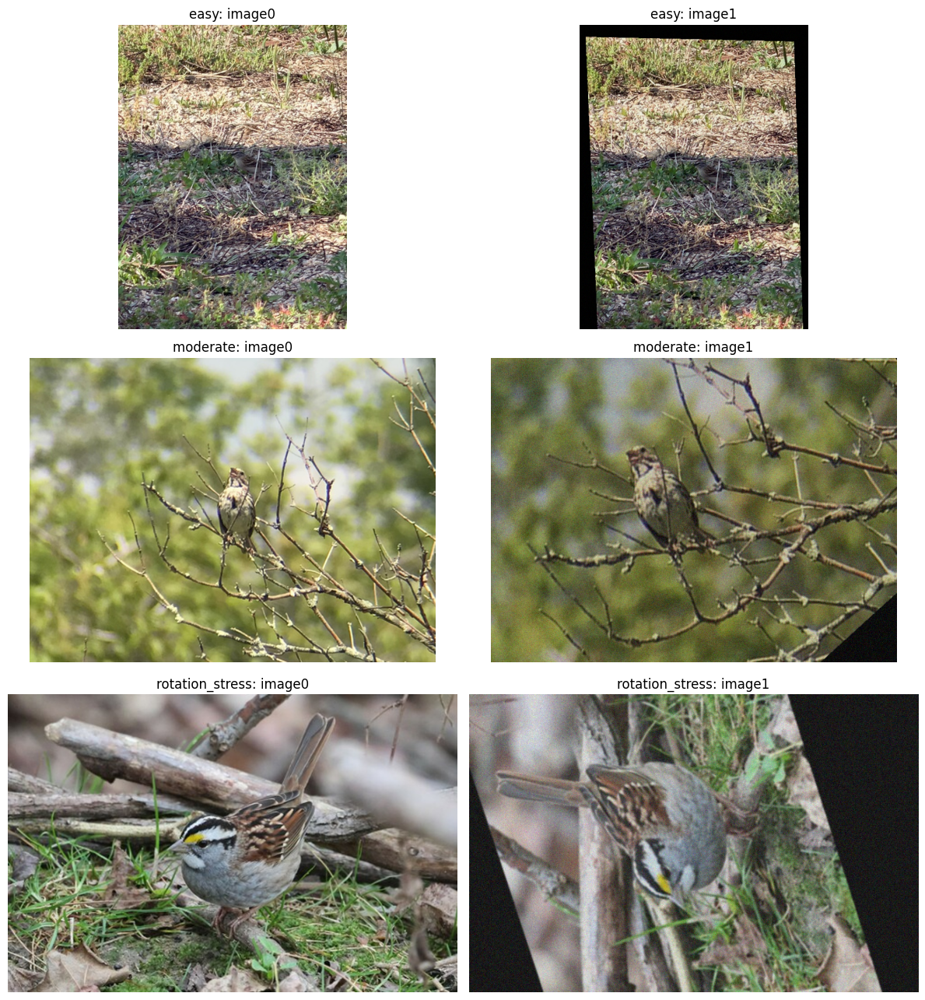

In [ ]:
# @title Visualize the exact three-tier pair bytes
import matplotlib.pyplot as plt
validation_pair_rows=[r for r in pair_rows if r["split"]=="validation"]
tiers_present=[t for t in TIERS if any(r["tier"]==t for r in validation_pair_rows)]
missing_tiers=[t for t in TIERS if t not in tiers_present]
if missing_tiers:
    print(f"No validation pair in tier(s) {missing_tiers}: tiers are assigned in turn (easy, moderate, rotation_stress) and this run has {len(validation_pair_rows)} validation pair(s). Use 13 or more photos to see every tier.")
fig,axes=plt.subplots(len(tiers_present),2,figsize=(12,13*len(tiers_present)/3),squeeze=False)
for row_i,tier in enumerate(tiers_present):
    row=next(r for r in validation_pair_rows if r["tier"]==tier)
    with Image.open(row["image0"]) as a, Image.open(row["image1"]) as b:
        axes[row_i,0].imshow(a); axes[row_i,1].imshow(b)
    axes[row_i,0].set_title(f"{tier}: image0"); axes[row_i,1].set_title(f"{tier}: image1")
    axes[row_i,0].axis("off"); axes[row_i,1].axis("off")
plt.tight_layout(); plt.savefig(OUTPUT_ROOT/"figures"/"difficulty_tiers.png",dpi=150,bbox_inches="tight"); plt.show()

## 8. Common geometric evaluator and model-neutral baselines

Every table from here on uses the same columns. Each returned correspondence is checked against the exact reference homography: its **reprojection error** is the distance in pixels between where the matcher put the point in image 1 and where the reference says it must be.

| Column | What it measures | Why it matters |
|---|---|---|
| `n` | number of pairs scored | per-tier rows have a third of the pairs, so one pair moves a per-tier rate a lot |
| `precision_1px` / `precision_3px` / `precision_5px` | per pair, the fraction of returned matches whose reprojection error is below 1, 3 or 5 px, averaged over pairs (a pair with no matches counts as 0) | how trustworthy the returned matches are |
| `matches_per_pair` | mean number of returned correspondences | density: how much the matcher gives you |
| `inliers_per_pair` | mean number of matches within 3 px | usable density: correct matches, not just matches |
| `median_error_px` | median reprojection error over all within-3-px matches pooled; empty (null) when there are none | how precisely the correct matches are localised |
| `homography_acc_3px` / `homography_acc_5px` | fraction of pairs where RANSAC-DLT, fitted to the matcher's correspondences, gives a homography whose four image corners land on average within 3 / 5 px of the reference corners (the **mean corner error**) | whether the matches are good enough for the downstream geometric task, e.g. stitching or registration |
| `corner_error_px` (per pair) | that mean corner error; infinite (null in exports) when RANSAC finds no homography | per-pair geometric success |
| `seconds` (baselines) | wall time of the baseline on this runtime | cost |

Read precision and density together: a matcher can be very precise with few matches, or dense with more errors.

Two model-neutral baselines use the same evaluator:

1. identity guess;
2. grayscale patch nearest-neighbour by normalized cross-correlation.

> **Before you run it:** predict whether this simple reference will be easy or difficult for the learned model(s) to beat. After the result appears, record the baseline value before looking at the more complex model comparison.

In [ ]:
# @title Common geometry metrics
import math
THRESHOLDS=(1.,3.,5.); INLIER_PX=3.

def warp_points(points,H):
    pts=np.asarray(points,float).reshape(-1,2); hom=np.concatenate([pts,np.ones((len(pts),1))],1)@np.asarray(H,float).T
    with np.errstate(divide="ignore",invalid="ignore"): return hom[:,:2]/hom[:,2:3]

def reprojection_errors(k0,k1,H):
    k0=np.asarray(k0,float).reshape(-1,2); k1=np.asarray(k1,float).reshape(-1,2)
    if len(k0)!=len(k1): raise ValueError("correspondence arrays differ in length")
    if not len(k0): return np.zeros(0)
    err=np.linalg.norm(warp_points(k0,H)-k1,axis=1); return np.where(np.isfinite(err),err,np.inf)

def ransac_homography(k0,k1,threshold=3.,iterations=500,seed=0):
    k0=np.asarray(k0,float).reshape(-1,2); k1=np.asarray(k1,float).reshape(-1,2); n=len(k0)
    if n<4:return None,np.zeros(n,bool)
    rng=np.random.default_rng(seed); best=np.zeros(n,bool)
    for _ in range(iterations):
        sample=rng.choice(n,4,replace=False); H=dlt_homography(k0[sample],k1[sample])
        if H is None: continue
        mask=reprojection_errors(k0,k1,H)<threshold
        if mask.sum()>best.sum():
            best=mask
            if best.sum()==n:break
    if best.sum()<4:return None,best
    H=dlt_homography(k0[best],k1[best]); return (None,best) if H is None else (H,reprojection_errors(k0,k1,H)<threshold)

def corner_error(est,ref,size):
    w,h=size; corners=np.array([[0.,0.],[w-1.,0.],[w-1.,h-1.],[0.,h-1.]])
    return float(np.linalg.norm(warp_points(corners,est)-warp_points(corners,ref),axis=1).mean())

def pair_metrics(match,H,size):
    k0=np.asarray(match["kpts0"],float).reshape(-1,2); k1=np.asarray(match["kpts1"],float).reshape(-1,2); errors=reprojection_errors(k0,k1,H)
    out={"n_matches":int(len(errors))}
    for t in THRESHOLDS: out[f"precision_{int(t)}px"]=float((errors<t).mean()) if len(errors) else 0.
    inliers=errors[errors<INLIER_PX]; out["n_inliers"]=int(len(inliers)); out["inlier_errors"]=inliers.tolist()
    est,_=ransac_homography(k0,k1,RANSAC_INLIER_PX,RANSAC_ITERATIONS,RANSAC_SEED)
    out["corner_error_px"]=corner_error(est,H,size) if est is not None else math.inf
    return out

def aggregate_metrics(rows):
    if not rows:  # a tier with no pairs (small BYOD sets): report n = 0 and undefined (null) metrics
        return {"n":0,**{k:math.nan for k in ("matches_per_pair","inliers_per_pair","median_error_px","homography_acc_3px","homography_acc_5px")},**{f"precision_{int(t)}px":math.nan for t in THRESHOLDS}}
    pooled=[e for r in rows for e in r["inlier_errors"]]
    out={"n":len(rows),"matches_per_pair":float(np.mean([r["n_matches"] for r in rows])),"inliers_per_pair":float(np.mean([r["n_inliers"] for r in rows])),
         "median_error_px":float(np.median(pooled)) if pooled else math.inf,"homography_acc_3px":float(np.mean([r["corner_error_px"]<3 for r in rows])),
         "homography_acc_5px":float(np.mean([r["corner_error_px"]<5 for r in rows]))}
    for t in THRESHOLDS: out[f"precision_{int(t)}px"]=float(np.mean([r[f"precision_{int(t)}px"] for r in rows]))
    return out

def grid_points(size,step=32,margin=16):
    w,h=size; xs=np.arange(margin,w-margin,step,float); ys=np.arange(margin,h-margin,step,float); gx,gy=np.meshgrid(xs,ys); return np.stack([gx.ravel(),gy.ravel()],1)

def identity_baseline(image0,image1,step=32):
    pts=grid_points(image0.size,step); return {"kpts0":pts,"kpts1":pts.copy(),"confidence":np.ones(len(pts))}

def _gray(image): return np.asarray(image.convert("L"),float)
def _ncc(patch,window):
    p=patch.shape[0]; h,w=window.shape
    if h<p or w<p:return np.zeros((0,0))
    windows=np.lib.stride_tricks.sliding_window_view(window,(p,p)); tiles=windows.reshape(windows.shape[0],windows.shape[1],-1); tiles-=tiles.mean(2,keepdims=True)
    flat=(patch-patch.mean()).ravel(); denom=np.sqrt((tiles**2).sum(2)*(flat**2).sum())+1e-9; return (tiles@flat)/denom

def patch_neighbour_baseline(image0,image1,step=32,patch=15,search=48):
    g0,g1=_gray(image0),_gray(image1); half=patch//2; pts=grid_points(image0.size,step,max(16,half+1)); k0=[];k1=[];conf=[]
    for x,y in pts:
        xi,yi=int(round(x)),int(round(y)); tile=g0[yi-half:yi+half+1,xi-half:xi+half+1]
        y0,y1=max(0,yi-search-half),min(g1.shape[0],yi+search+half+1); x0,x1=max(0,xi-search-half),min(g1.shape[1],xi+search+half+1)
        scores=_ncc(tile,g1[y0:y1,x0:x1])
        if not scores.size:continue
        best=np.unravel_index(int(np.argmax(scores)),scores.shape); k0.append([x,y]); k1.append([x0+best[1]+half,y0+best[0]+half]); conf.append(float(scores[best]))
    return {"kpts0":np.asarray(k0,float).reshape(-1,2),"kpts1":np.asarray(k1,float).reshape(-1,2),"confidence":np.asarray(conf,float)}

## 9. Validation baselines

**Predict before running:** Predict whether identity matching or local patch search will retain more geometrically correct correspondences as tier difficulty increases.


In [ ]:
# @title Model-neutral validation baselines
import time

def evaluate_callable(rows,matcher_fn,method):
    per=[]; started=time.perf_counter()
    for row in rows:
        with Image.open(row["image0"]) as a, Image.open(row["image1"]) as b:
            a.load();b.load();match=matcher_fn(a.convert("RGB"),b.convert("RGB"))
        met=pair_metrics(match,np.asarray(row["homography"]),(row["width"],row["height"])); met.update({"pair_id":row["pair_id"],"tier":row["tier"],"method":method}); per.append(met)
    agg=aggregate_metrics(per); agg["seconds"]=time.perf_counter()-started; return per,agg

validation_baselines={};validation_baseline_rows=[]
if RUN_IDENTITY_BASELINE:
    rows,agg=evaluate_callable(validation_pair_rows,identity_baseline,"identity");validation_baselines["identity"]=agg;validation_baseline_rows+=rows
if RUN_PATCH_BASELINE:
    rows,agg=evaluate_callable(validation_pair_rows,patch_neighbour_baseline,"patch_neighbour");validation_baselines["patch_neighbour"]=agg;validation_baseline_rows+=rows
display(pd.DataFrame([{"method":k,**v} for k,v in validation_baselines.items()]))

,method,n,matches_per_pair,inliers_per_pair,median_error_px,homography_acc_3px,homography_acc_5px,precision_1px,precision_3px,precision_5px,seconds
0,identity,48,261.25,1.187500,2.085603,0.0000,0.0000,0.000649,0.005054,0.011973,1.830958
1,patch_neighbour,48,261.25,68.541667,0.511144,0.3125,0.3125,0.235994,0.267207,0.273121,142.690086


> **What to notice.** The identity guess keeps every grid point where it was, so it is right only where the warp barely moved the image; expect values near zero, highest on easy pairs. That is the floor. The patch neighbour searches only ±48 px around each point with a fixed upright patch, so it should do clearly better on easy pairs than on rotated ones. Write down both `homography_acc_3px` values: a learned matcher has added something only if it beats them on the same pairs.

## 10. Build the isolated comparative matching environment

The model frontend runs in a separate Python 3.12 environment, built with `uv` whatever Python the notebook kernel uses, pinned to `vismatch==1.3.2`, `torch==2.14.0`, and `torchvision==0.29.0`.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [ ]:
# @title Create isolated vismatch environment
import subprocess, sys, os
MODEL_ENV_PYTHON="3.12"; UV_PIN="uv==0.8.17"

def run_checked(cmd,label):
    """Run one step in a child process; on failure, show the tail of its output."""
    env=dict(os.environ); env["MPLBACKEND"]="Agg"
    completed=subprocess.run([str(part) for part in cmd],check=False,text=True,capture_output=True,env=env)
    if completed.returncode!=0:
        raise RuntimeError(
            f"{label} failed with exit code {completed.returncode}.\n"
            f"--- stderr (tail) ---\n{completed.stderr[-4000:]}\n"
            f"--- stdout (tail) ---\n{completed.stdout[-2000:]}"
        )
    return completed

def ensure_uv():
    probe=subprocess.run([sys.executable,"-m","uv","--version"],check=False,capture_output=True,text=True)
    if probe.returncode!=0: run_checked([sys.executable,"-m","pip","install","--quiet",UV_PIN],f"install {UV_PIN}")

# The environment lives under the shared work root, so BYOD runs reuse it (no second multi-GB install).
ENV_ROOT=SHARED_WORK_ROOT/"envs"/"vismatch"; ENV_PYTHON=ENV_ROOT/("Scripts/python.exe" if os.name=="nt" else "bin/python")
PINS=["vismatch==1.3.2","torch==2.14.0","torchvision==0.29.0"]
signature=hashlib.sha256("\n".join([f"python=={MODEL_ENV_PYTHON}",*PINS]).encode()).hexdigest(); marker=ENV_ROOT/".dimer_ready"
if not (ENV_PYTHON.is_file() and marker.is_file() and marker.read_text().strip()==signature):
    if ENV_ROOT.exists(): shutil.rmtree(ENV_ROOT)
    ensure_uv()
    run_checked([sys.executable,"-m","uv","venv","--seed","--python",MODEL_ENV_PYTHON,str(ENV_ROOT)],"create the vismatch environment")
    run_checked([str(ENV_PYTHON),"-m","pip","install","--quiet",*PINS],"install the vismatch environment pins")
    marker.write_text(signature,encoding="utf-8")
print({"python":str(ENV_PYTHON),"pins":PINS})

{'python': 'work/envs/vismatch/bin/python', 'pins': ['vismatch==1.3.2', 'torch==2.14.0', 'torchvision==0.29.0']}


## 11. Standalone model runner

The runner writes one NPZ per pair with only `kpts0`, `kpts1`, and `confidence`. All scoring remains in the common notebook evaluator. It also searches the runtime package/cache for filenames known to the current DIMER profiles and records any direct digest parity it can establish. An unlocated file is reported as `not-located`, never as verified.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [ ]:
# @title Write common matcher runner
MATCH_RUNNER = (
    '\n'
    'import argparse, hashlib, json, platform, site, time\n'
    'from pathlib import Path\n'
    'import numpy as np\n'
    'KNOWN={\n'
    ' "lightglue":{"backend":"aliked-lightglue","assets":{"aliked_lightglue.pth":[47632827,"d975e965b105311a6143194852297dff4f02aea5cc2e10cecfed966ca0e22503"],"aliked-n16.pth":[2738091,"5be8704840ed662d9d8c561bf7279c222092674e7eb05fd0feab94899e9d82f2"],"aliked_lightglue.safetensors":[47564948,"9c630a386c74c534428370ce46253e1d0968655db180f97074cb6ad797bd2bc6"],"aliked-n16.safetensors":[2719928,"3c8ca40c0c985cd4d641e96e4b408b14d067b5b3521ac17b36590447d49d115a"]}},\n'
    ' "xoftr":{"backend":"xoftr","assets":{"xoftr_640.safetensors":[44419304,"4d5ed62e8b41f862ecc5c660e31f1c450402966623d6a28e85acf7fbd794cc69"]}},\n'
    '}\n'
    'def sha(path):\n'
    ' h=hashlib.sha256();\n'
    ' with open(path,"rb") as f:\n'
    '  for chunk in iter(lambda:f.read(1<<20),b""):h.update(chunk)\n'
    ' return h.hexdigest()\n'
    'def find_assets(expected):\n'
    ' roots=[Path.home()/".cache"]\n'
    ' try: roots.extend(Path(x) for x in site.getsitepackages())\n'
    ' except Exception: pass\n'
    ' out={}\n'
    ' for name,(size,digest) in expected.items():\n'
    '  found=[]\n'
    '  for root in roots:\n'
    '   if not root.exists():continue\n'
    '   try:\n'
    '    for path in root.rglob(name):\n'
    '     if path.is_file():found.append(path)\n'
    '   except Exception:continue\n'
    '  if not found:out[name]={"status":"not-located"}\n'
    '  else:\n'
    '   rows=[]\n'
    '   for path in found[:8]:\n'
    '    actual_size=path.stat().st_size; actual_sha=sha(path); rows.append({"path":str(path),"bytes":actual_size,"sha256":actual_sha,"matches_dimer_pin":actual_size==size and actual_sha==digest})\n'
    '   out[name]={"status":"located","candidates":rows}\n'
    ' return out\n'
    'def normalize_match_result(result):\n'
    ' k0=np.asarray(result.get("matched_kpts0",[]),dtype=np.float32)\n'
    ' k1=np.asarray(result.get("matched_kpts1",[]),dtype=np.float32)\n'
    ' if not k0.size:k0=k0.reshape(0,2)\n'
    ' if not k1.size:k1=k1.reshape(0,2)\n'
    ' if k0.ndim!=2 or k1.ndim!=2 or k0.shape[1]!=2 or k1.shape[1]!=2 or len(k0)!=len(k1):\n'
    '  raise ValueError("Matcher must return equal Nx2 correspondence arrays")\n'
    ' conf=result.get("matched_confidences")\n'
    ' conf=np.ones(len(k0),np.float32) if conf is None else np.asarray(conf,np.float32).reshape(-1)\n'
    ' if len(conf)!=len(k0):raise ValueError("Matcher confidence count differs from correspondences")\n'
    ' if not all(np.isfinite(x).all() for x in (k0,k1,conf)):\n'
    '  raise ValueError("Matcher returned nonfinite coordinates or confidence")\n'
    ' return k0,k1,conf\n'
    '\n'
    'from contextlib import contextmanager\n'
    'import importlib\n'
    'import os\n'
    'import tempfile\n'
    'import urllib.request\n'
    '\n'
    'ASSET_URLS={\n'
    " 'aliked_lightglue.pth':'https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/aliked_lightglue.pth',\n"
    " 'aliked-n16.pth':'https://raw.githubusercontent.com/Shiaoming/ALIKED/683d7c65197395c0b3f01ebe76e1084a27e73a65/models/aliked-n16.pth',\n"
    " 'xoftr_640.safetensors':'https://huggingface.co/vismatch/xoftr/resolve/d8ee7d89be3c9e5c157db3886db1c0f0e038b321/xoftr_640.safetensors',\n"
    '}\n'
    'URL_REQUESTS={\n'
    " 'https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/aliked_lightglue.pth':'aliked_lightglue.pth',\n"
    " 'https://github.com/Shiaoming/ALIKED/raw/main/models/aliked-n16.pth':'aliked-n16.pth',\n"
    '}\n'
    '\n'
    'def verify_asset(path,name):\n'
    " expected=KNOWN['xoftr' if name.startswith('xoftr') else 'lightglue']['assets'][name]\n"
    ' if Path(path).stat().st_size!=expected[0] or sha(path)!=expected[1]:\n'
    "  raise ValueError(f'Checkpoint integrity failure before deserialization: {name}')\n"
    ' return Path(path)\n'
    '\n'
    'def stage_asset(name,root):\n'
    ' path=Path(root)/name;path.parent.mkdir(parents=True,exist_ok=True)\n'
    ' if path.exists():return verify_asset(path,name)\n'
    " request=urllib.request.Request(ASSET_URLS[name],headers={'User-Agent':'DIMER-image-matching/1.0'})\n"
    " fd,temp=tempfile.mkstemp(prefix='asset-',dir=path.parent)\n"
    ' try:\n'
    "  with os.fdopen(fd,'wb') as output,urllib.request.urlopen(request,timeout=120) as response:\n"
    '   while chunk:=response.read(1<<20):output.write(chunk)\n'
    '  verify_asset(temp,name)\n'
    '  os.replace(temp,path)\n'
    ' finally:\n'
    '  if os.path.exists(temp):os.unlink(temp)\n'
    ' return path\n'
    '\n'
    '@contextmanager\n'
    'def verified_checkpoint_loaders(key,torch_module,root):\n'
    ' """Restrict the exact acquisition calls used by vismatch1.3.2, then restore them."""\n'
    ' original_hub=torch_module.hub.load_state_dict_from_url\n'
    ' module=None;original_snapshot=None;original_safe=None\n'
    ' loaded=[]\n'
    ' def restricted_hub(url,*args,**kwargs):\n'
    "  if key!='lightglue' or url not in URL_REQUESTS:raise ValueError(f'Unapproved checkpoint URL: {url}')\n"
    '  name=URL_REQUESTS[url];path=stage_asset(name,root)\n'
    '  # Recheck at the actual deserialization boundary even when a cache exists.\n'
    '  verify_asset(path,name)\n'
    "  state=torch_module.load(str(path),map_location='cpu',weights_only=True)\n"
    "  loaded.append({'name':name,'sha256':sha(path),'loading':'torch.load(weights_only=True)'})\n"
    '  return state\n'
    ' try:\n'
    '  torch_module.hub.load_state_dict_from_url=restricted_hub\n'
    "  if key=='xoftr':\n"
    "   module=importlib.import_module('vismatch.im_models.xoftr')\n"
    '   original_snapshot=module.snapshot_download;original_safe=module.load_file\n'
    "   path=stage_asset('xoftr_640.safetensors',root)\n"
    '   def restricted_snapshot(repo_id,*args,**kwargs):\n'
    "    if repo_id!='vismatch/xoftr' or args or kwargs:raise ValueError('Unapproved XoFTR snapshot request')\n"
    "    verify_asset(path,'xoftr_640.safetensors')\n"
    '    return str(path.parent)\n'
    '   def restricted_safe(filename,*args,**kwargs):\n'
    "    if Path(filename).resolve()!=path.resolve():raise ValueError('Unapproved XoFTR checkpoint path')\n"
    "    verify_asset(path,'xoftr_640.safetensors')\n"
    '    state=original_safe(str(path),*args,**kwargs)\n'
    "    loaded.append({'name':path.name,'sha256':sha(path),'loading':'safetensors'})\n"
    '    return state\n'
    '   module.snapshot_download=restricted_snapshot;module.load_file=restricted_safe\n'
    '  yield loaded\n'
    "  required={'aliked-n16.pth','aliked_lightglue.pth'} if key=='lightglue' else {'xoftr_640.safetensors'}\n"
    "  if {row['name'] for row in loaded}!=required:raise RuntimeError('Backend did not consume every verified checkpoint')\n"
    ' finally:\n'
    '  torch_module.hub.load_state_dict_from_url=original_hub\n'
    '  if module is not None:\n'
    '   module.snapshot_download=original_snapshot;module.load_file=original_safe\n'
    '\n'
    'def main():\n'
    ' ap=argparse.ArgumentParser();ap.add_argument("--model",choices=["lightglue","xoftr"],required=True);ap.add_argument("--pairs",required=True);ap.add_argument("--out-dir",required=True);ap.add_argument("--metadata",required=True);args=ap.parse_args()\n'
    ' pairs=json.loads(Path(args.pairs).read_text());out_dir=Path(args.out_dir);out_dir.mkdir(parents=True,exist_ok=True)\n'
    ' import torch,vismatch\n'
    ' from vismatch import get_matcher\n'
    ' device="cuda" if torch.cuda.is_available() else "cpu"\n'
    ' if torch.cuda.is_available():torch.cuda.reset_peak_memory_stats()\n'
    ' started=time.perf_counter()\n'
    ' with verified_checkpoint_loaders(args.model,torch,Path.home()/".cache"/"dimer-matching-verified") as verified_assets:\n'
    '  matcher=get_matcher(KNOWN[args.model]["backend"],device=device)\n'
    ' load_seconds=time.perf_counter()-started\n'
    ' started=time.perf_counter();counts=[]\n'
    ' for row in pairs:\n'
    '  img0=matcher.load_image(row["image0"],resize=None);img1=matcher.load_image(row["image1"],resize=None);result=matcher(img0,img1)\n'
    '  k0,k1,conf=normalize_match_result(result)\n'
    '  np.savez_compressed(out_dir/f"{row[\'pair_id\']}.npz",kpts0=k0,kpts1=k1,confidence=conf);counts.append(len(k0))\n'
    ' inference_seconds=time.perf_counter()-started;peak=int(torch.cuda.max_memory_allocated()) if torch.cuda.is_available() else None\n'
    ' meta={"model":args.model,"backend_name":KNOWN[args.model]["backend"],"execution_backend":"vismatch","vismatch_version":getattr(vismatch,"__version__","unknown"),"python":platform.python_version(),"torch":torch.__version__,"device":device,"pairs":len(pairs),"load_seconds":load_seconds,"inference_seconds":inference_seconds,"seconds_per_pair":inference_seconds/max(len(pairs),1),"matches_per_pair_raw":float(np.mean(counts)) if counts else 0.,"peak_cuda_bytes":peak,"verified_assets_consumed":verified_assets,"dimer_asset_parity_observations":find_assets(KNOWN[args.model]["assets"])}\n'
    ' Path(args.metadata).write_text(json.dumps(meta,indent=2),encoding="utf-8")\n'
    'if __name__=="__main__":main()\n'
)
runner_path=WORK_ROOT/"runners"/"run_matcher.py";runner_path.write_text(MATCH_RUNNER,encoding="utf-8");compile(MATCH_RUNNER,str(runner_path),"exec")
print("runner_sha256:",hashlib.sha256(MATCH_RUNNER.encode()).hexdigest())

runner_sha256: 2f739b37199a10eb2143ba3d03231533d1abb14c985a4683e6a53464a78addbf


## 12. Frozen-model validation

**Predict before running:** Predict which model will yield more matches and whether that also means higher precision. Compare both with the validation baselines.


In [ ]:
# @title Run both models on validation
validation_pair_manifest=OUTPUT_ROOT/"data"/"validation_pairs.json";validation_pair_manifest.write_text(json.dumps(validation_pair_rows,indent=2),encoding="utf-8")
validation_runtime={}
for key in MODEL_KEYS:
    out_dir=OUTPUT_ROOT/"validation"/"matches"/key;out_dir.mkdir(parents=True,exist_ok=True);meta=OUTPUT_ROOT/"validation"/f"{key}_runtime.json"
    run_checked([ENV_PYTHON,runner_path,"--model",key,"--pairs",validation_pair_manifest,"--out-dir",out_dir,"--metadata",meta],f"{key} validation matching")
    validation_runtime[key]=json.loads(meta.read_text())
display(pd.DataFrame([{"model":MODEL_SPECS[k]["display_name"],"device":validation_runtime[k]["device"],"seconds_per_pair":validation_runtime[k]["seconds_per_pair"],"raw_matches_per_pair":validation_runtime[k]["matches_per_pair_raw"]} for k in MODEL_KEYS]))
if any(validation_runtime[k]["device"]!="cuda" for k in MODEL_KEYS):
    print("Warning: No CUDA GPU was used by the matchers, so they ran on the CPU. The results stay valid but the run is much slower; for the documented runtime select a T4 GPU and start a fresh session.")

,model,device,seconds_per_pair,raw_matches_per_pair
0,LightGlue + ALIKED,cuda,0.177420,689.062500
1,XoFTR,cuda,0.282284,2126.958333


In [ ]:
# @title Common validation scoring
def load_model_match(root,pair_id):
    data=np.load(Path(root)/f"{pair_id}.npz",allow_pickle=False);return {"kpts0":data["kpts0"],"kpts1":data["kpts1"],"confidence":data["confidence"]}
def evaluate_saved_matches(rows,key,split):
    root=OUTPUT_ROOT/split/"matches"/key;per=[]
    for row in rows:
        met=pair_metrics(load_model_match(root,row["pair_id"]),np.asarray(row["homography"]),(row["width"],row["height"]));met.update({"pair_id":row["pair_id"],"tier":row["tier"],"method":key});per.append(met)
    return per,aggregate_metrics(per),{tier:aggregate_metrics([r for r in per if r["tier"]==tier]) for tier in TIERS}
validation_models={};validation_model_rows=[];validation_tiers={}
for key in MODEL_KEYS:
    rows,overall,by_tier=evaluate_saved_matches(validation_pair_rows,key,"validation");validation_models[key]=overall;validation_model_rows+=rows;validation_tiers[key]=by_tier
validation_compare={**validation_baselines,**validation_models}
display(pd.DataFrame([{"method":m,**v} for m,v in validation_compare.items()]))
tier_rows=[]
for method,tiers in validation_tiers.items():
    for tier,values in tiers.items():tier_rows.append({"method":method,"tier":tier,**values})
print("Overall validation table above; the same metrics per difficulty tier:")
display(pd.DataFrame(tier_rows))

,method,n,matches_per_pair,inliers_per_pair,median_error_px,homography_acc_3px,homography_acc_5px,precision_1px,precision_3px,precision_5px,seconds
0,identity,48,261.250000,1.187500,2.085603,0.000000,0.000000,0.000649,0.005054,0.011973,1.830958
1,patch_neighbour,48,261.250000,68.541667,0.511144,0.312500,0.312500,0.235994,0.267207,0.273121,142.690086
2,lightglue,48,689.062500,668.791667,0.325960,0.729167,0.729167,0.549177,0.758364,0.790927,NaN
3,xoftr,48,2126.958333,1977.875000,0.436871,0.687500,0.729167,0.501418,0.657897,0.680426,NaN


Overall validation table above; the same metrics per difficulty tier:


,method,tier,n,matches_per_pair,inliers_per_pair,median_error_px,homography_acc_3px,homography_acc_5px,precision_1px,precision_3px,precision_5px
0,lightglue,easy,16,1063.5000,1059.7500,0.179441,0.9375,0.9375,0.938295,0.985107,0.993827
1,lightglue,moderate,16,793.3750,775.2500,0.777925,1.0000,1.0000,0.590854,0.976124,0.998934
2,lightglue,rotation_stress,16,210.3125,171.3750,1.060022,0.2500,0.2500,0.118383,0.313860,0.380021
3,xoftr,easy,16,3997.1875,3948.1875,0.325721,0.9375,1.0000,0.896063,0.974469,0.981785
4,xoftr,moderate,16,2070.0000,1813.9375,0.767777,0.9375,0.9375,0.504056,0.802309,0.843231
5,xoftr,rotation_stress,16,313.6875,171.5000,0.818556,0.1875,0.2500,0.104134,0.196913,0.216261


> **What to notice.** Check your prediction from section 12 against the first table: which matcher returned more matches (`matches_per_pair`), and did it also have the higher `precision_3px`? Then use the per-tier table to see whether the ordering holds on every tier or only on easy pairs. There are only 16 validation pairs per tier, so one pair changes a per-tier homography accuracy by 0.0625; treat small gaps as noise.

## 13. Freeze before the independent test

The frozen record fixes corpus identity, split, pair-generation tiers/seeds, model identities, execution backend, known DIMER checkpoint digests, geometric thresholds, RANSAC settings, baselines, and validation observations.

> **What to notice.** Nothing was tuned on the validation pairs, but freezing still matters: from here on the settings cannot be changed in response to test results. The printed path is the record you can show someone to prove the test was not chosen after the fact.

In [ ]:
# @title Freeze experiment
def pairs_digest(rows):
    payload=[[r["pair_id"],r["source_id"],r["tier"],r["seed"],r["image0_sha256"],r["image1_sha256"],r["homography"]] for r in rows]
    return hashlib.sha256(strict_json_dumps(payload,separators=(",",":")).encode()).hexdigest()
frozen={"notebook_spec":"2.1","profile":"TASK-INFERENCE","mode":"WORKSHOP","corpus":photo_manifest_out,
        "pair_generator":{"version":"dimer-comparative-homography-v1","working_long_side":WORKING_LONG_SIDE,"tiers":TIER_PARAMS,"split_seed":SPLIT_SEED,"validation_pair_digest":pairs_digest(validation_pair_rows)},
        "models":MODEL_SPECS,"execution_backend":{"package":"vismatch==1.3.2","runner_sha256":hashlib.sha256(MATCH_RUNNER.encode()).hexdigest(),"exact_dimer_weight_parity":"qualification-required"},
        "evaluation":{"precision_thresholds_px":list(THRESHOLDS),"inlier_threshold_px":INLIER_PX,"ransac_threshold_px":RANSAC_INLIER_PX,"ransac_iterations":RANSAC_ITERATIONS,"ransac_seed":RANSAC_SEED},
        "validation":{"baselines":validation_baselines,"models":validation_models,"by_tier":validation_tiers,"runtime":validation_runtime}}
freeze_path=OUTPUT_ROOT/"frozen"/"frozen_experiment.json";freeze_path.write_text(strict_json_dumps(frozen,indent=2,default=str),encoding="utf-8");print("Frozen:",freeze_path)

Frozen: outputs/frozen/frozen_experiment.json


## 14. Independent test

**Predict before running:** The experiment is frozen. Predict whether validation trends persist on the held-out photographs; do not revise the recipe after seeing test results.


In [ ]:
# @title Verify freeze and open final test pairs
frozen_loaded=json.loads((OUTPUT_ROOT/"frozen"/"frozen_experiment.json").read_text());assert frozen_loaded["pair_generator"]["validation_pair_digest"]==pairs_digest(validation_pair_rows);assert frozen_loaded["execution_backend"]["package"]=="vismatch==1.3.2"
test_pair_rows=[r for r in pair_rows if r["split"]=="test"];test_pair_manifest=OUTPUT_ROOT/"data"/"test_pairs.json";test_pair_manifest.write_text(json.dumps(test_pair_rows,indent=2),encoding="utf-8")
print(pd.DataFrame(test_pair_rows).groupby("tier").size())

tier
easy               32
moderate           32
rotation_stress    32
dtype: int64


In [ ]:
# @title Test baselines and model inference
test_baselines={};test_baseline_rows=[]
if RUN_IDENTITY_BASELINE:
    rows,agg=evaluate_callable(test_pair_rows,identity_baseline,"identity");test_baselines["identity"]=agg;test_baseline_rows+=rows
if RUN_PATCH_BASELINE:
    rows,agg=evaluate_callable(test_pair_rows,patch_neighbour_baseline,"patch_neighbour");test_baselines["patch_neighbour"]=agg;test_baseline_rows+=rows

test_runtime={}
for key in MODEL_KEYS:
    out_dir=OUTPUT_ROOT/"test"/"matches"/key;meta=OUTPUT_ROOT/"test"/f"{key}_runtime.json"
    run_checked([ENV_PYTHON,runner_path,"--model",key,"--pairs",test_pair_manifest,"--out-dir",out_dir,"--metadata",meta],f"{key} test matching")
    test_runtime[key]=json.loads(meta.read_text())

In [ ]:
# @title Common test evaluation
test_models={};test_model_rows=[];test_tiers={}
for key in MODEL_KEYS:
    rows,overall,by_tier=evaluate_saved_matches(test_pair_rows,key,"test");test_models[key]=overall;test_model_rows+=rows;test_tiers[key]=by_tier
test_compare={**test_baselines,**test_models}
aggregate_table=pd.DataFrame([{"method":m,**v} for m,v in test_compare.items()])
tier_table=pd.DataFrame([{"method":m,"tier":tier,**values} for m in MODEL_KEYS for tier,values in test_tiers[m].items()])
display(aggregate_table);display(tier_table)
aggregate_table.to_csv(OUTPUT_ROOT/"test"/"aggregate_metrics.csv",index=False);tier_table.to_csv(OUTPUT_ROOT/"test"/"per_tier_metrics.csv",index=False)
per_pair_df=pd.DataFrame([{**{k:v for k,v in row.items() if k!="inlier_errors"},"median_pair_inlier_error":float(np.median(row["inlier_errors"])) if row["inlier_errors"] else math.inf} for row in test_baseline_rows+test_model_rows]);per_pair_df.to_csv(OUTPUT_ROOT/"test"/"per_pair_metrics.csv",index=False)

,method,n,matches_per_pair,inliers_per_pair,median_error_px,homography_acc_3px,homography_acc_5px,precision_1px,precision_3px,precision_5px,seconds
0,identity,96,267.187500,0.989583,2.264219,0.000000,0.000000,0.000307,0.003615,0.009461,5.406817
1,patch_neighbour,96,267.187500,63.802083,0.590934,0.333333,0.354167,0.191479,0.241806,0.250553,218.371214
2,lightglue,96,723.552083,704.385417,0.374404,0.822917,0.822917,0.601145,0.817671,0.844306,NaN
3,xoftr,96,2224.947917,2088.791667,0.475456,0.718750,0.718750,0.521836,0.665331,0.691283,NaN


,method,tier,n,matches_per_pair,inliers_per_pair,median_error_px,homography_acc_3px,homography_acc_5px,precision_1px,precision_3px,precision_5px
0,lightglue,easy,32,1161.68750,1161.46875,0.240732,1.00000,1.00000,0.963849,0.999665,1.000000
1,lightglue,moderate,32,697.87500,688.00000,0.657060,1.00000,1.00000,0.647346,0.980865,0.997746
2,lightglue,rotation_stress,32,311.09375,263.68750,1.081874,0.46875,0.46875,0.192240,0.472483,0.535172
3,xoftr,easy,32,3973.31250,3921.62500,0.383946,1.00000,1.00000,0.903153,0.985046,0.991828
4,xoftr,moderate,32,2245.56250,2014.43750,0.701675,0.93750,0.93750,0.528814,0.780176,0.818371
5,xoftr,rotation_stress,32,455.96875,330.31250,0.732505,0.21875,0.21875,0.133540,0.230772,0.263650


> **What to notice.** These are the headline numbers: 96 test pairs never used before, 32 per tier. Compare each matcher with the baselines first, then with each other, and then with what you predicted from validation. One test pair changes a per-tier homography accuracy by about 0.031. The tables are saved as `test/aggregate_metrics.csv` and `test/per_tier_metrics.csv`.

## 15. Robustness across difficulty

Read precision, match density, inlier count, and homography accuracy together. The rotation-stress tier is deliberately severe and is not assumed to represent the frequency of normal deployment conditions.

In [ ]:
# @title Difficulty degradation
degradation_rows=[]
for key in MODEL_KEYS:
    easy=test_tiers[key]["easy"]
    for tier in ("moderate","rotation_stress"):
        cur=test_tiers[key][tier];degradation_rows.append({"model":MODEL_SPECS[key]["display_name"],"tier":tier,"precision_3px_drop":easy["precision_3px"]-cur["precision_3px"],"inliers_per_pair_drop":easy["inliers_per_pair"]-cur["inliers_per_pair"],"homography_acc_3px_drop":easy["homography_acc_3px"]-cur["homography_acc_3px"]})
degradation=pd.DataFrame(degradation_rows);display(degradation);degradation.to_csv(OUTPUT_ROOT/"test"/"difficulty_degradation.csv",index=False)

,model,tier,precision_3px_drop,inliers_per_pair_drop,homography_acc_3px_drop
0,LightGlue + ALIKED,moderate,0.018800,473.46875,0.00000
1,LightGlue + ALIKED,rotation_stress,0.527183,897.78125,0.53125
2,XoFTR,moderate,0.204870,1907.18750,0.06250
3,XoFTR,rotation_stress,0.754274,3591.31250,0.78125


> **What to notice.** Each value is the easy-tier result minus the harder tier's result, so a **larger positive number means a larger drop**. Compare the two matchers' drops for `rotation_stress`: robustness is how little a method loses, not how high it starts.

## 16. Pair-level disagreement analysis

In [ ]:
# @title Cross-model pair table
lg=pd.DataFrame([r for r in test_model_rows if r["method"]=="lightglue"]);xf=pd.DataFrame([r for r in test_model_rows if r["method"]=="xoftr"])
compare=lg[["pair_id","tier","precision_3px","n_inliers","n_matches","corner_error_px"]].rename(columns={"precision_3px":"lightglue_precision_3px","n_inliers":"lightglue_inliers","n_matches":"lightglue_matches","corner_error_px":"lightglue_corner_error"}).merge(xf[["pair_id","precision_3px","n_inliers","n_matches","corner_error_px"]].rename(columns={"precision_3px":"xoftr_precision_3px","n_inliers":"xoftr_inliers","n_matches":"xoftr_matches","corner_error_px":"xoftr_corner_error"}),on="pair_id",validate="one_to_one")
compare["precision_advantage_lightglue"]=compare["lightglue_precision_3px"]-compare["xoftr_precision_3px"];compare["inlier_difference"]=compare["lightglue_inliers"]-compare["xoftr_inliers"];compare["lightglue_h_success"]=compare["lightglue_corner_error"]<3;compare["xoftr_h_success"]=compare["xoftr_corner_error"]<3
compare.to_csv(OUTPUT_ROOT/"test"/"disagreements.csv",index=False);print("Five test pairs where LightGlue + ALIKED is most ahead on precision@3px (precision_advantage_lightglue > 0):")
display(compare.sort_values("precision_advantage_lightglue",ascending=False).head())
print("Five test pairs where XoFTR is most ahead (precision_advantage_lightglue < 0):")
display(compare.sort_values("precision_advantage_lightglue").head())

Five test pairs where LightGlue + ALIKED is most ahead on precision@3px (precision_advantage_lightglue > 0):


,pair_id,tier,lightglue_precision_3px,lightglue_inliers,lightglue_matches,lightglue_corner_error,xoftr_precision_3px,xoftr_inliers,xoftr_matches,xoftr_corner_error,precision_advantage_lightglue,inlier_difference,lightglue_h_success,xoftr_h_success
11,test-011,rotation_stress,0.956835,399,417,0.901414,0.019802,2,101,260.645149,0.937033,397,True,False
28,test-028,moderate,0.951613,708,744,1.202244,0.027273,12,440,279.457077,0.924340,696,True,False
76,test-076,moderate,0.921824,283,307,1.838748,0.000000,0,75,302.457790,0.921824,283,True,False
92,test-092,rotation_stress,0.897959,352,392,1.003374,0.012270,2,163,232.614024,0.885689,350,True,False
50,test-050,rotation_stress,0.871658,326,374,2.870065,0.019608,1,51,365.080271,0.852050,325,True,False


Five test pairs where XoFTR is most ahead (precision_advantage_lightglue < 0):


,pair_id,tier,lightglue_precision_3px,lightglue_inliers,lightglue_matches,lightglue_corner_error,xoftr_precision_3px,xoftr_inliers,xoftr_matches,xoftr_corner_error,precision_advantage_lightglue,inlier_difference,lightglue_h_success,xoftr_h_success
23,test-023,rotation_stress,0.702403,380,541,2.220465,0.794224,220,277,0.987002,-0.091821,160,True,True
19,test-019,moderate,0.945000,189,200,0.602866,0.955311,2950,3088,0.770507,-0.010311,-2761,True,True
80,test-080,rotation_stress,0.000000,0,7,353.371729,0.004717,1,212,530.735251,-0.004717,-1,False,False
8,test-008,rotation_stress,0.000000,0,18,359.078147,0.000000,0,11,384.512847,0.000000,0,False,False
26,test-026,rotation_stress,0.000000,0,56,428.286146,0.000000,0,4,350.410511,0.000000,0,False,False


> **What to notice.** Look at the `tier` column of each table: do the pairs where one matcher wins cluster in one tier? `lightglue_h_success` / `xoftr_h_success` show whether each matcher's matches still gave a homography within 3 px. A pair where one matcher succeeds and the other fails is the most useful kind of disagreement to examine in the plots of section 17 (they show the first test pair of each tier).

## 17. Correspondence visualization

Green lines are 3-px reference inliers and red lines are outliers. The visualization uses a deterministic evenly spaced subset of matches; metrics use all correspondences.

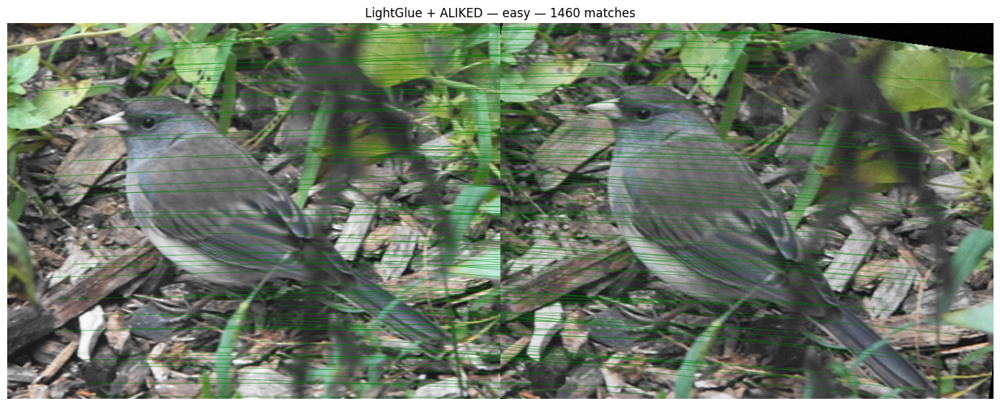

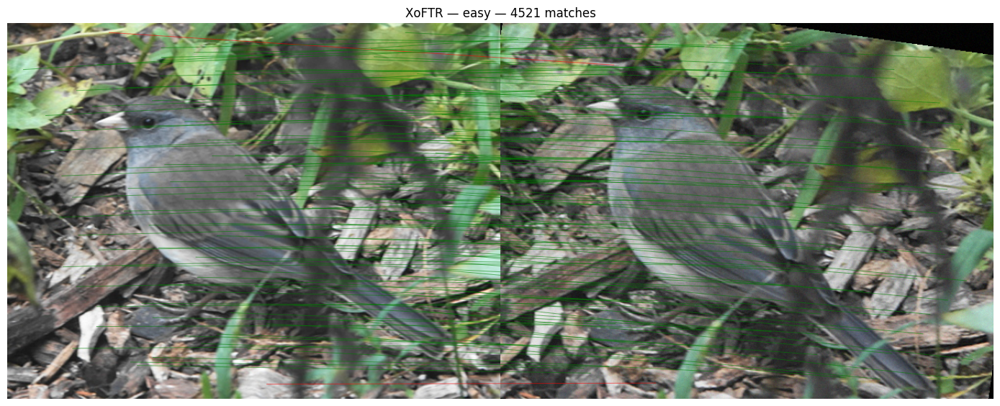

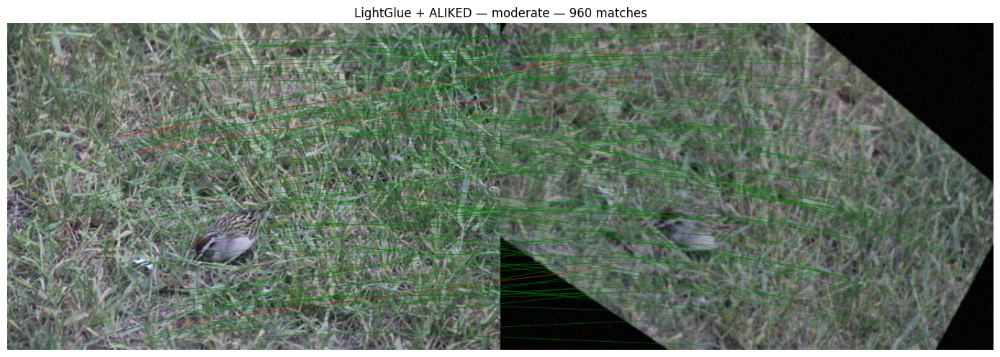

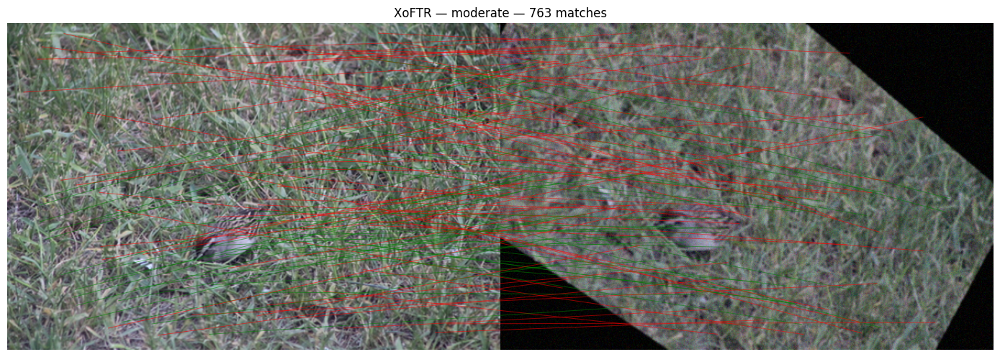

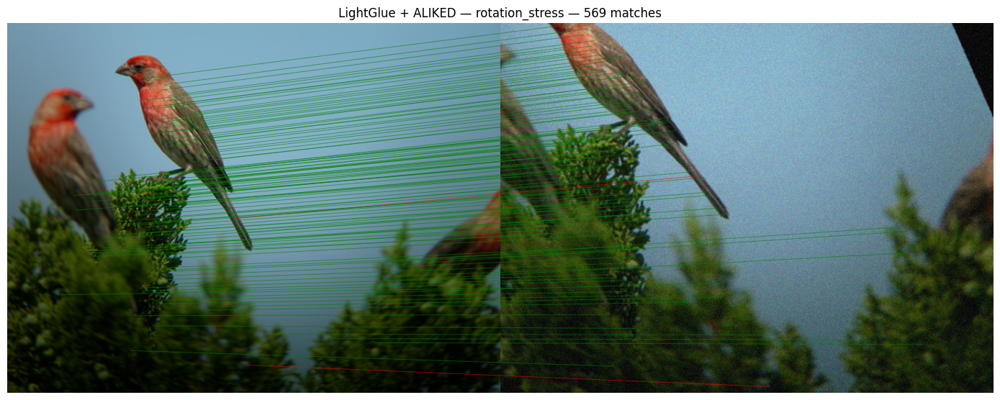

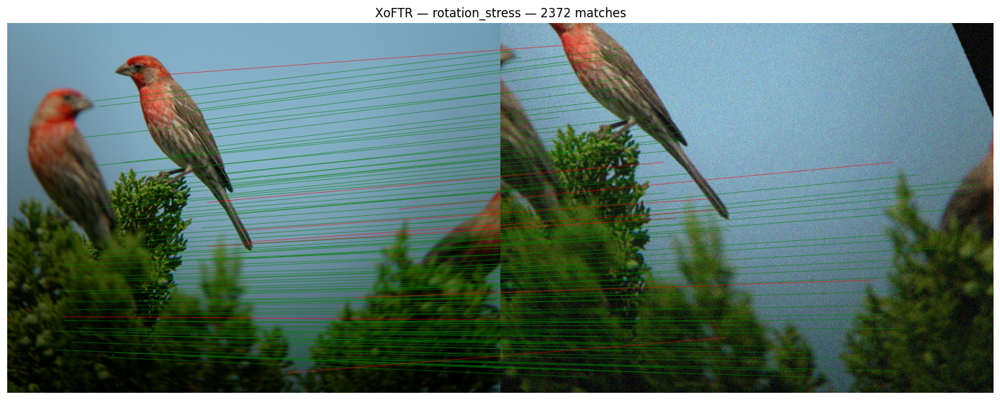

In [ ]:
# @title Visualize first test pair from each tier for both models
def draw_matches(row,key,max_lines=120):
    match=load_model_match(OUTPUT_ROOT/"test"/"matches"/key,row["pair_id"]);k0=np.asarray(match["kpts0"]);k1=np.asarray(match["kpts1"]);errors=reprojection_errors(k0,k1,np.asarray(row["homography"]))
    with Image.open(row["image0"]) as a, Image.open(row["image1"]) as b:
        a=a.convert("RGB");b=b.convert("RGB");canvas=Image.new("RGB",(a.width+b.width,max(a.height,b.height)));canvas.paste(a,(0,0));canvas.paste(b,(a.width,0))
    fig,ax=plt.subplots(figsize=(14,6));ax.imshow(canvas)
    if len(k0):
        idx=np.linspace(0,len(k0)-1,min(max_lines,len(k0))).astype(int)
        for i in idx:
            ax.plot([k0[i,0],a.width+k1[i,0]],[k0[i,1],k1[i,1]],linewidth=.7,alpha=.55,color="green" if errors[i]<3 else "red")
    ax.set_title(f"{MODEL_SPECS[key]['display_name']} — {row['tier']} — {len(k0)} matches");ax.axis("off");plt.tight_layout();return fig
for tier in TIERS:
    row=next((r for r in test_pair_rows if r["tier"]==tier),None)
    if row is None:
        print(f"No test pair in tier {tier!r} in this run; its correspondence plot is skipped.")
        continue
    for key in MODEL_KEYS:
        fig=draw_matches(row,key);fig.savefig(OUTPUT_ROOT/"figures"/f"{tier}_{key}_matches.png",dpi=150,bbox_inches="tight");plt.show()

## 18. Match density and runtime

Compute cost is part of the central question. The scatter plot puts each test pair at its match count (x) and precision@3px (y), one colour per matcher. The runtime table separates `load_seconds` (checkpoint verification and model construction) from `inference_seconds` (matching all test pairs, including image loading), and reports peak GPU memory; geometric evaluation runs in the notebook and is not included. The last table lists, per checkpoint, whether the file the backend used was located and matched the DIMER pin (full detail is in `provenance/experiment_manifest.json`).

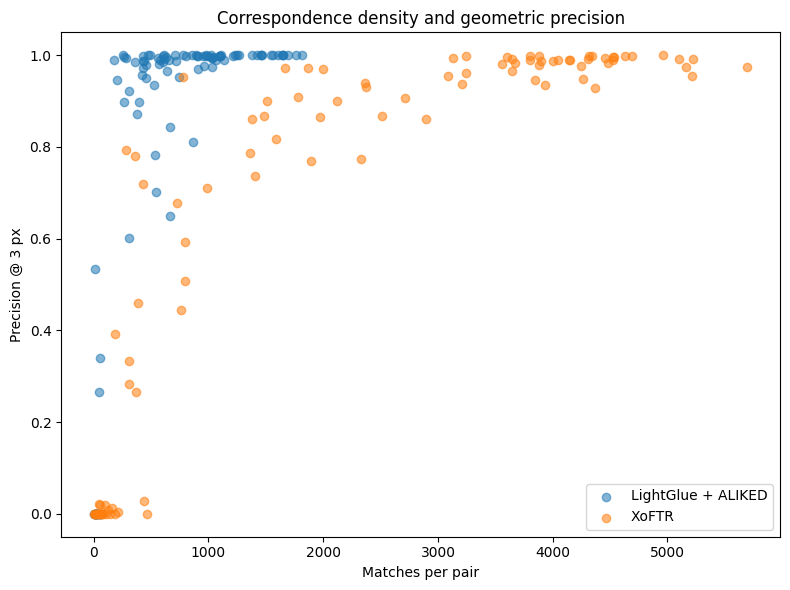

,model,execution_backend,device,load_seconds,inference_seconds,seconds_per_pair,raw_matches_per_pair,peak_vram_MiB
0,LightGlue + ALIKED,vismatch,cuda,1.646231,15.863283,0.165243,723.552083,1669.412109
1,XoFTR,vismatch,cuda,3.185960,27.884246,0.290461,2224.947917,2967.583496


Checkpoint parity observations (full detail in provenance/experiment_manifest.json):


,model,asset,status,matches_dimer_pin
0,LightGlue + ALIKED,aliked_lightglue.pth,located,True
1,LightGlue + ALIKED,aliked-n16.pth,located,True
2,LightGlue + ALIKED,aliked_lightglue.safetensors,not-located,None
3,LightGlue + ALIKED,aliked-n16.safetensors,not-located,None
4,XoFTR,xoftr_640.safetensors,located,True


In [ ]:
# @title Density versus precision and runtime table
fig,ax=plt.subplots(figsize=(8,6))
for key in MODEL_KEYS:
    x=compare["lightglue_matches"].to_numpy() if key=="lightglue" else compare["xoftr_matches"].to_numpy();y=compare["lightglue_precision_3px"].to_numpy() if key=="lightglue" else compare["xoftr_precision_3px"].to_numpy();ax.scatter(x,y,alpha=.55,label=MODEL_SPECS[key]["display_name"])
ax.set_xlabel("Matches per pair");ax.set_ylabel("Precision @ 3 px");ax.set_title("Correspondence density and geometric precision");ax.legend();plt.tight_layout();plt.savefig(OUTPUT_ROOT/"figures"/"density_vs_precision.png",dpi=150,bbox_inches="tight");plt.show()
runtime_table=pd.DataFrame([{"model":MODEL_SPECS[k]["display_name"],"execution_backend":test_runtime[k]["execution_backend"],"device":test_runtime[k]["device"],"load_seconds":test_runtime[k]["load_seconds"],"inference_seconds":test_runtime[k]["inference_seconds"],"seconds_per_pair":test_runtime[k]["seconds_per_pair"],"raw_matches_per_pair":test_runtime[k]["matches_per_pair_raw"],"peak_vram_MiB":test_runtime[k]["peak_cuda_bytes"]/2**20 if test_runtime[k]["peak_cuda_bytes"] is not None else None} for k in MODEL_KEYS]);display(runtime_table);runtime_table.to_csv(OUTPUT_ROOT/"test"/"runtime.csv",index=False)
parity_rows=[]
for key in MODEL_KEYS:
    for asset,obs in test_runtime[key]["dimer_asset_parity_observations"].items():
        candidates=obs.get("candidates",[])
        parity_rows.append({"model":MODEL_SPECS[key]["display_name"],"asset":asset,"status":obs.get("status"),
                            "matches_dimer_pin":any(c.get("matches_dimer_pin") for c in candidates) if candidates else None})
print("Checkpoint parity observations (full detail in provenance/experiment_manifest.json):")
display(pd.DataFrame(parity_rows))

> **What to notice.** In the scatter plot, does one matcher sit to the right (more matches) but lower (less precise)? In the runtime table, compare `seconds_per_pair` and `peak_vram_MiB`: a denser matcher usually costs more. Times depend on the GPU and include image loading; compare the two matchers on the same run rather than with numbers from another runtime. In the parity table, `not-located` for an unused `.safetensors` variant is expected; a checkpoint the backend actually used should show `matches_dimer_pin = True`.

## 19. New-pair inference without ground truth

The next pair has no independent reference homography, so correspondence counts are valid inference output but geometric precision is **not measurable**.

In [ ]:
# @title Draw an unlabelled pair and run both matchers
from PIL import ImageDraw
future_dir=OUTPUT_ROOT/"future";future_dir.mkdir(parents=True,exist_ok=True)
a=Image.new("RGB",(640,480),"white");d=ImageDraw.Draw(a);d.rectangle((80,80,260,260),outline="black",width=8);d.ellipse((350,120,520,290),outline="black",width=8);d.line((100,400,540,350),fill="black",width=10)
b=Image.new("RGB",(640,480),"white");d=ImageDraw.Draw(b);d.rectangle((120,105,300,285),outline="black",width=8);d.ellipse((385,145,555,315),outline="black",width=8);d.line((140,425,580,375),fill="black",width=10)
p0=future_dir/"drawn_0.png";p1=future_dir/"drawn_1.png";a.save(p0);b.save(p1)
unlabelled=[{"pair_id":"drawn-unlabelled","image0":str(p0.resolve()),"image1":str(p1.resolve())}];manifest=future_dir/"unlabelled_pairs.json";manifest.write_text(json.dumps(unlabelled,indent=2),encoding="utf-8")
for key in MODEL_KEYS:
    out=future_dir/key;out.mkdir(exist_ok=True);meta=future_dir/f"{key}_runtime.json";run_checked([ENV_PYTHON,runner_path,"--model",key,"--pairs",manifest,"--out-dir",out,"--metadata",meta],f"{key} unlabelled-pair matching");match=load_model_match(out,"drawn-unlabelled");print(MODEL_SPECS[key]["display_name"],"matches:",len(match["kpts0"]))
print("Evaluation status: not-measurable — no independent reference geometry.")

LightGlue + ALIKED matches: 226


XoFTR matches: 880
Evaluation status: not-measurable — no independent reference geometry.


## 20. BYOD

First-release BYOD accepts a directory or ZIP of photographs and creates deterministic synthetic homography pairs locally. This keeps the evaluation measurable without inventing real-pair ground truth.

User-supplied imagery remains inside the selected notebook runtime and is not sent to a DIMER worker/API. A hosted notebook remains an external compute environment; do not upload confidential, biometric, surveillance, restricted, regulated, security-sensitive, or proprietary imagery unless authorized.

To use it, set `USE_BYOD=True` and `BYOD_PATH` (a folder or a `.zip`) in section 1, or in Colab leave `BYOD_PATH` empty to get an upload dialog for one `.zip`, then **Run all**. You can do this in the same runtime after the default run: the matcher environment and the verified checkpoints are reused. Supply 4–360 JPEG/PNG photographs, 16–4096 pixels per side; duplicate decoded images are rejected even when their file bytes differ. Pair tiers are assigned in turn (easy, moderate, rotation_stress) within each split, so with fewer than 13 photos some tiers have no validation or test pair: their rows show `n = 0` with empty metrics and their figures are skipped.

The BYOD split is a random split by photo, which assumes your photographs are independent of each other. Near-duplicates (burst shots, crops of one scene) are not detected and can land in both validation and test; nothing is trained here, so this only makes the test less independent. The same split → synthetic pair generation → validation → freeze → held-out model inference → geometric evaluation → report export runs for BYOD. Every BYOD run gets an isolated `OUTPUT_DIR/byod/run-*` output folder (and its own work folder) and its own report ZIP next to that folder; the canonical report ZIP leaves the `byod/` folder out, so your photographs' pairs, matches and figures never enter it. ZIP extraction uses a unique directory and rejects duplicate members, traversal and symlinks. BYOD establishes synthetic-warp behavior on supplied photographs, not accuracy on genuine scene pairs.


## 21. Why this notebook does not adapt either model

There is no adaptation step to run here: the canonical comparison is frozen-model inference. The existing DIMER E2E tutorials expose materially different adaptation contracts: LightGlue trains final matcher layers + assignment head while ALIKED remains frozen; XoFTR trains final coarse layers + projection while the backbone/fine stage remain frozen. Those adapted results should stay separate from this common frozen comparison.

## 22. Interpretation and limitations

- Synthetic homographies provide exact reference geometry but do not reproduce parallax, non-planar depth, occlusion/disocclusion, or independent object motion.
- ±150° rotation is a deliberate stress tier, not an assumption about normal workloads.
- Match scores are not calibrated probabilities and are not comparable across model families on a common probability scale.
- High precision can still fail geometric estimation if correspondences are too few, clustered, or nearly collinear.
- Both systems may return plausible-looking correspondences on unrelated/weak-overlap image pairs; downstream geometric verification remains necessary.
- This **candidate** executes both methods through `vismatch==1.3.2`; exact DIMER checkpoint parity must be demonstrated during release qualification before claiming execution parity with the live DIMER profiles.

## 23. Exercises

1. **Sparse vs detector-free:** Which matcher should return more correspondences, and why?
2. **Precision vs density:** Is 40 matches at 99% precision better than 2,000 matches at 95%? What downstream task changes the answer?
3. **Rotation:** Which matcher degrades more under ±150° rotation stress? Use measured data rather than architecture assumptions.
4. **Homography:** Why can high match precision still yield a bad homography?
5. **Transfer:** How might this experiment change for drone frames, satellite registration, thermal/visible pairs, or historical photographs?

<details>
<summary><b>Guidance for the exercises (read after answering)</b></summary>

1. A detector-free matcher proposes matches on a dense feature grid, so it usually returns more correspondences than a sparse matcher limited to detected keypoints. Check `matches_per_pair` in section 14.
2. It depends on the task: a homography needs only a handful of well-spread correct matches, so high precision wins; dense 3-D reconstruction or flow benefits from density. Compare `inliers_per_pair` with `precision_3px`.
3. Use the `rotation_stress` rows of the section 15 table and the per-tier test table; the answer is whatever your run measured.
4. RANSAC needs enough correct matches spread across the image; a few precise matches clustered in one corner or along a line give an unstable homography. Look for pairs with high `precision_3px` but `h_success = False` in section 16.
5. Real pairs add parallax, occlusion and appearance change that a planar synthetic warp cannot show, and many lack an exact reference homography, so accuracy may become not-measurable as in section 19.

</details>

## 24. Export provenance and report bundle

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [ ]:
# @title Final provenance
import datetime, shutil
experiment_manifest={
 "notebook_spec":"2.1","notebook_profile":"TASK-INFERENCE","notebook_mode":"WORKSHOP","workshop_revision":"0.1.0-candidate","timestamp_utc":datetime.datetime.now(datetime.timezone.utc).isoformat(),
 "dataset_source":dataset_source,"corpus_manifest":photo_manifest_out,
 "pair_generator":{"version":"dimer-comparative-homography-v1","working_long_side":WORKING_LONG_SIDE,"tiers":TIER_PARAMS,"split_seed":SPLIT_SEED,"validation_pairs":len(validation_pair_rows),"test_pairs":len(test_pair_rows),"validation_digest":pairs_digest(validation_pair_rows),"test_digest":pairs_digest(test_pair_rows)},
 "models":MODEL_SPECS,
 "execution_backend":{"package":"vismatch==1.3.2","runner_sha256":hashlib.sha256(MATCH_RUNNER.encode()).hexdigest(),"runtime":test_runtime,"dimer_checkpoint_parity_status":"qualification-required"},
 "evaluation":{"precision_thresholds_px":list(THRESHOLDS),"inlier_threshold_px":INLIER_PX,"ransac_threshold_px":RANSAC_INLIER_PX,"ransac_iterations":RANSAC_ITERATIONS,"ransac_seed":RANSAC_SEED,"aggregate":aggregate_table.to_dict("records"),"per_tier":tier_table.to_dict("records")},
 "standalone_contract":{"repository_clone_required":False,"dimer_source_runtime_fetch_required":False,"external_dimer_worker_required":False,"credentials_required":False,"default_upload_required":False},
 "undefined_metric_policy":"Nonfinite metrics are exported as null: no measurable homography/inlier statistic; never interpreted as zero error.",
 "evidence_scope":("Synthetic homography evaluation on user-supplied photographs" if USE_BYOD else "Synthetic homography evaluation on a pinned tutorial corpus")+"; sample-sanity evidence, not benchmark evidence."
}
(OUTPUT_ROOT/"provenance"/"experiment_manifest.json").write_text(strict_json_dumps(experiment_manifest,indent=2,default=str),encoding="utf-8")
(OUTPUT_ROOT/"workshop_summary.json").write_text(strict_json_dumps({"models":[MODEL_SPECS[k]["display_name"] for k in MODEL_KEYS],"validation_pairs":len(validation_pair_rows),"test_pairs":len(test_pair_rows),"aggregate_metrics":aggregate_table.to_dict("records"),"per_tier_metrics":tier_table.to_dict("records")},indent=2,default=str),encoding="utf-8")
def write_report_bundle(root,target,exclude_top=()):
    """Zip one run's output folder; the canonical bundle leaves earlier BYOD runs (byod/) out."""
    root=Path(root).resolve()
    with zipfile.ZipFile(target,"w",zipfile.ZIP_DEFLATED) as archive:
        for path in sorted(root.rglob("*")):
            rel=path.relative_to(root)
            if rel.parts[0] in exclude_top: continue
            archive.write(path,rel.as_posix())
    return str(target)
excluded=() if USE_BYOD else ("byod",)
bundle=write_report_bundle(OUTPUT_DIR,str(Path(OUTPUT_DIR).resolve())+"_DIMER_Image_Matching_Workshop_Report.zip",excluded)
if excluded and (Path(OUTPUT_DIR)/"byod").exists():
    print("Earlier BYOD runs under", Path(OUTPUT_DIR)/"byod", "were left out of this canonical report; each has its own report ZIP.")
print({"report_bundle":bundle,"sha256":sha256_file(bundle)})

{'report_bundle': '/content/outputs_DIMER_Image_Matching_Workshop_Report.zip', 'sha256': 'e38ec41929566d7081e460f0049bbd2b96e3096a00722d725c1188f05911587e'}


## Try it yourself — one controlled change

**Predict → change one variable → run → observe → explain.** The one variable is the correctness tolerance: how close to the reference a match must be to count as correct (3 px in every table so far).

1. **Predict.** When the tolerance tightens from 3 px to `ACTIVITY_STRICT_TOLERANCE_PX` (1 px by default), which matcher keeps the larger *share* of its correct matches, and is the answer the same on every tier? Write your prediction down, with a reason.
2. **Change.** Either tick `RUN_TOLERANCE_ACTIVITY` in section 1 before **Run all**, or, after a completed run, type `RUN_TOLERANCE_ACTIVITY = True` in a new code cell (add `ACTIVITY_STRICT_TOLERANCE_PX = 0.5` there to try another tolerance between 0 and 3 px), run it, then run the next cell. Do not re-run section 1 for this after a BYOD run: that starts a new, empty BYOD run folder.
3. **Observe.** The table shows, per matcher and tier, precision at 3 px, precision at the strict tolerance, and `retained_fraction` = strict ÷ 3 px.
4. **Explain.** Connect what you see to the `median_error_px` column of the validation table.

The cell re-scores the saved **validation** correspondences only. It loads no model and writes no files, and the frozen settings and test results are unchanged.


In [ ]:
# @title Try it yourself: tighten the correctness tolerance (optional)
if not RUN_TOLERANCE_ACTIVITY:
    print("Activity not run: switch RUN_TOLERANCE_ACTIVITY on as described above, then run this cell. It loads no model and writes no files.")
else:
    if not 0 < float(ACTIVITY_STRICT_TOLERANCE_PX) < 3:
        raise ValueError(f"ACTIVITY_STRICT_TOLERANCE_PX must be greater than 0 and smaller than 3 px; got {ACTIVITY_STRICT_TOLERANCE_PX}")
    if not all((OUTPUT_ROOT/"validation"/"matches"/key).is_dir() for key in MODEL_KEYS):
        raise RuntimeError(f"No saved validation matches under {OUTPUT_ROOT/'validation'/'matches'}: complete a Run all first, and do not re-run section 1 before this cell.")
    activity_tolerances=(3.0,float(ACTIVITY_STRICT_TOLERANCE_PX))
    activity_rows=[]
    for key in MODEL_KEYS:
        matches_root=OUTPUT_ROOT/"validation"/"matches"/key
        for tier in TIERS:
            tier_rows_=[r for r in validation_pair_rows if r["tier"]==tier]
            if not tier_rows_: continue
            errors=[]
            for r in tier_rows_:
                saved=load_model_match(matches_root,r["pair_id"])
                errors.append(reprojection_errors(saved["kpts0"],saved["kpts1"],np.asarray(r["homography"])))
            row={"model":MODEL_SPECS[key]["display_name"],"tier":tier,"pairs":len(tier_rows_)}
            for tol in activity_tolerances:
                row[f"precision_{tol:g}px"]=float(np.mean([float((e<tol).mean()) if len(e) else 0. for e in errors]))
            strict=row[f"precision_{activity_tolerances[1]:g}px"]; loose=row["precision_3px"]
            row["retained_fraction"]=strict/loose if loose>0 else math.nan
            activity_rows.append(row)
    print(f"Validation precision at 3 px and at {activity_tolerances[1]:g} px (saved correspondences re-scored; nothing written):")
    print(pd.DataFrame(activity_rows).to_string(index=False))

Activity not run: switch RUN_TOLERANCE_ACTIVITY on as described above, then run this cell. It loads no model and writes no files.


<details>
<summary><b>Sample interpretation (read after you have run and explained)</b></summary>

Precision can only stay the same or fall when the tolerance tightens, so compare the **retained fraction**, not the raw drop. A matcher whose correct matches sit very close to the reference (low `median_error_px`) keeps most of them at 1 px; one whose matches are roughly right but less precisely localised loses more, even if its 3 px precision was similar. If the ordering changes between tiers, the harder warps are degrading localisation, not just producing more outright wrong matches. Use the numbers from **your** run: with 16 validation pairs per tier, small differences are not meaningful.

</details>

## Self-paced checkpoint

Before reading the sample interpretation, answer in your own words:

1. What was the model or system asked to do?
2. Which baseline/reference tells you whether the model added useful capability?
3. What is the most important failure mode or tradeoff visible in this notebook?
4. What would you need to test before applying the result to a different dataset or operational setting?

<details>
<summary><b>Show a sample interpretation</b></summary>

More raw matches do not automatically mean better matching. Give more weight to geometrically consistent correspondences and failure patterns across difficulty tiers than to match count alone.

A complete answer should cite the outputs from **your run**, because small numerical differences can occur across supported runtimes.

</details>


## Write an evidence-based conclusion

Use the outputs from your run rather than declaring a universal winner.

1. **State the question.** What capability or comparison did this notebook test?
2. **Report the primary result.** Compare the relevant model/system with its baseline or reference on the held-out or otherwise designated evaluation data.
3. **Add supporting evidence.** Include the most informative secondary metric, error pattern, qualitative diagnostic, or disagreement.
4. **Account for cost or complexity.** Mention runtime, model footprint, extra stages, or adaptation when they materially affect the comparison.
5. **State the limits.** Say what this dataset, split, model revision, and configuration do—and do not—support.

Compare the selected matchers on held-out geometric quality and runtime, identify at least one pair type where their behavior differs, and avoid generalizing the result beyond the controlled image corpus and evaluator.


## Glossary

| Term | Meaning |
|---|---|
| Keypoint | Distinctive image coordinate used by sparse feature methods |
| Descriptor | Vector describing local image appearance |
| Correspondence | Matched coordinates across two images |
| Sparse matcher | Matches detected local features, e.g. ALIKED + LightGlue |
| Detector-free matcher | Predicts matches from image feature grids without a separate detector |
| Homography | 3×3 projective mapping between planar image coordinates |
| Reprojection error | Pixel distance from a predicted correspondence to the exact reference warp |
| Inlier | Match within the chosen geometric threshold |
| RANSAC | Robust estimator using repeated minimal correspondence samples |
| DLT | Direct Linear Transform homography estimator |
| Precision@3px | Fraction of returned matches within 3 px of reference geometry |
| Homography accuracy@3px | Fraction of pairs whose RANSAC-DLT homography puts the image corners within 3 px of the reference on average |
| Mean corner error | Average distance between the four image corners mapped by the estimated and by the reference homography |
| Match density | Number of correspondences returned per pair |
| Sample-sanity evidence | Bounded tutorial measurement, not a benchmark claim |

In [ ]:
# @title Run-all completion summary
completion={"notebook_spec":"2.1","profile":"TASK-INFERENCE","mode":"WORKSHOP","models":[MODEL_SPECS[k]["display_name"] for k in MODEL_KEYS],"execution_backend":"vismatch==1.3.2","dataset_source":dataset_source,"photos":len(photo_records),"validation_pairs":len(validation_pair_rows),"test_pairs":len(test_pair_rows),"tiers":list(TIERS),"output_directory":str(OUTPUT_ROOT.resolve()),"dimer_checkpoint_parity":"qualification-required"}
display(pd.Series(completion,name="value").to_frame())
print("Canonical comparative workflow complete. Release still requires clean-runtime execution and exact DIMER asset-parity qualification.")

,value
notebook_spec,2.1
profile,TASK-INFERENCE
mode,WORKSHOP
models,"[LightGlue + ALIKED, XoFTR]"
execution_backend,vismatch==1.3.2
dataset_source,pinned iNaturalist CC0 matching corpus
photos,360
validation_pairs,48
test_pairs,96
tiers,"[easy, moderate, rotation_stress]"


Canonical comparative workflow complete. Release still requires clean-runtime execution and exact DIMER asset-parity qualification.


## Troubleshooting

| Symptom | Likely cause | Corrective action |
|---|---|---|
| Photo digest mismatch | changed/interrupted source object | delete the cached file and retry; never bypass the pin |
| Kernel Python is older than 3.10 | unsupported notebook kernel | use a current hosted runtime; the matcher environment uses Python 3.12 regardless |
| Environment creation fails in section 10 | `uv` could not install or download Python 3.12, or a pin failed to install | check network access, then rerun section 10; the error shows the tail of the installer output |
| A matching step fails with a `RuntimeError` naming the step | the matcher process exited with an error | read the stderr tail in the message; it is the matcher's own error |
| CUDA unavailable | CPU runtime selected | use T4 or equivalent for practical execution |
| Matcher returns zero matches | severe warp, low texture, or model failure mode | treat it as a real zero-match observation |
| Rotation-stress result collapses | model is not robust to that regime | interpret it as measured stress behaviour |
| Patch baseline is slow | CPU NCC is intentionally simple | keep it for qualified release evidence; disable only during exploratory edits |
| BYOD ZIP refused | unsafe path, symlink, or size | correct the archive rather than bypassing validation |
| A BYOD photo is refused | the message names the file and the rule (count, size, duplicate pixels, not a ZIP) | fix or remove that file and run again from section 1 |
| BYOD tables show `n = 0` for a tier | fewer than 13 photos, so that tier has no validation or test pair | add photographs; the other tiers are still valid |
| Package/version or stale-module error after installation | the kernel imported incompatible libraries before the run | start a fresh runtime and choose **Run all** before importing extra packages |
| Out-of-memory or session restart | the GPU or RAM is too small for the matcher | use a T4 or larger; each matcher runs in its own process, one at a time |
| Your numbers differ slightly from a recorded run | GPU kernels and library builds introduce small numerical differences | compare the pattern, metric definitions, split and model revision before treating a difference as meaningful |
| RANSAC homography fails | fewer than four usable matches / degenerate geometry | count the pair as geometric-estimation failure |
| DIMER parity remains qualification-required | backend asset parity not proven | verify exact model asset identities during release qualification |